<a href="https://colab.research.google.com/github/sakthiprasanth16/fish-image-classification/blob/main/Fish_model_building.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Mount Drive and check GPU

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

# GPU check
import tensorflow as tf
print("TensorFlow version:", tf.__version__)
gpus = tf.config.list_physical_devices('GPU')
print("Num GPUs Available:", len(gpus))
print(gpus)

if len(gpus) == 0:
    print("No GPU detected. In Colab: Runtime -> Change runtime type -> Hardware accelerator -> GPU, then reconnect and run this cell again.")
else:
    print("GPU detected - good to go.")


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
TensorFlow version: 2.19.0
Num GPUs Available: 1
[PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]
GPU detected - good to go.


# Imports, paths, hyperparameters, utilities

In [ ]:
import os, gc, json
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns

from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.models import Sequential, Model, load_model
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout, GlobalAveragePooling2D
from tensorflow.keras.callbacks import ModelCheckpoint, EarlyStopping
from tensorflow.keras.optimizers import Adam

# Paths
DATA_DIR = '/content/drive/MyDrive/data/fish_dataset'
TRAIN_DIR = os.path.join(DATA_DIR, 'train')
VAL_DIR = os.path.join(DATA_DIR, 'val')
TEST_DIR = os.path.join(DATA_DIR, 'test')
SAVE_DIR = '/content/drive/MyDrive/fish_models'
os.makedirs(SAVE_DIR, exist_ok=True)

# Hyperparams
IMG_SIZE = (256, 256)
BATCH_SIZE = 32
EPOCHS = 3
SEED = 42

# Reproducibility
import random
random.seed(SEED); np.random.seed(SEED)
import tensorflow as tf
tf.random.set_seed(SEED)

# save class indices
def save_class_indices(gen, path):
    with open(path, 'w') as f:
        json.dump(gen.class_indices, f, indent=2)

# Data generators (train/val/test)

In [ ]:
train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=20,
    zoom_range=0.2,
    horizontal_flip=True,
    width_shift_range=0.1,
    height_shift_range=0.1,
    shear_range=0.1,
    fill_mode='nearest'
)

val_test_datagen = ImageDataGenerator(rescale=1./255)

train_gen = train_datagen.flow_from_directory(
    TRAIN_DIR, target_size=IMG_SIZE, batch_size=BATCH_SIZE,
    class_mode='categorical', shuffle=True, seed=SEED
)

val_gen = val_test_datagen.flow_from_directory(
    VAL_DIR, target_size=IMG_SIZE, batch_size=BATCH_SIZE,
    class_mode='categorical', shuffle=False, seed=SEED
)

test_gen = val_test_datagen.flow_from_directory(
    TEST_DIR, target_size=IMG_SIZE, batch_size=BATCH_SIZE,
    class_mode='categorical', shuffle=False
)

# Save mapping
save_class_indices(train_gen, os.path.join(SAVE_DIR, 'class_indices.json'))
print("Classes:", train_gen.class_indices)


Found 6753 images belonging to 11 classes.
Found 1179 images belonging to 11 classes.
Found 3490 images belonging to 11 classes.
Classes: {'animal fish': 0, 'animal fish bass': 1, 'fish sea_food black_sea_sprat': 2, 'fish sea_food gilt_head_bream': 3, 'fish sea_food hourse_mackerel': 4, 'fish sea_food red_mullet': 5, 'fish sea_food red_sea_bream': 6, 'fish sea_food sea_bass': 7, 'fish sea_food shrimp': 8, 'fish sea_food striped_red_mullet': 9, 'fish sea_food trout': 10}


# Plotting training history and evaluation

In [ ]:
def plot_training(history, model_name):
    plt.figure(figsize=(12,5))
    # Accuracy
    plt.subplot(1,2,1)
    plt.plot(history.history.get('accuracy', []), label='train_acc')
    plt.plot(history.history.get('val_accuracy', []), label='val_acc')
    plt.title(f'{model_name} Accuracy')
    plt.xlabel('Epoch'); plt.ylabel('Accuracy'); plt.legend()
    # Loss
    plt.subplot(1,2,2)
    plt.plot(history.history.get('loss', []), label='train_loss')
    plt.plot(history.history.get('val_loss', []), label='val_loss')
    plt.title(f'{model_name} Loss')
    plt.xlabel('Epoch'); plt.ylabel('Loss'); plt.legend()
    plt.tight_layout()
    plt.savefig(os.path.join(SAVE_DIR, f'plot_{model_name}.png'))
    plt.show()

def evaluate_and_report(model, generator, class_indices):
    # Evaluate on generator
    loss, acc = model.evaluate(generator, verbose=1)
    print(f"Test loss: {loss:.4f} | Test accuracy: {acc:.4f}")

    # Predictions
    generator.reset()
    preds = model.predict(generator, verbose=1)
    y_pred = np.argmax(preds, axis=1)
    y_true = generator.classes
    class_names = list(class_indices.keys())
    print("\nClassification Report:\n")
    print(classification_report(y_true, y_pred, target_names=class_names))
    # Confusion matrix
    cm = confusion_matrix(y_true, y_pred)
    plt.figure(figsize=(10,8))
    sns.heatmap(cm, annot=True, fmt='d', xticklabels=class_names, yticklabels=class_names, cmap='Blues')
    plt.xlabel('Predicted'); plt.ylabel('Actual'); plt.title('Confusion Matrix')
    plt.show()
    return {'loss': loss, 'accuracy': acc}

# Custom CNN model

In [ ]:
from tensorflow.keras.layers import Input
from tensorflow.keras import regularizers

def create_custom_cnn(input_shape=(256,256,3), num_classes=3):
    model = Sequential([
        Input(shape=input_shape),
        Conv2D(32, (3,3), activation='relu', padding='same'),
        MaxPooling2D((2,2)),

        Conv2D(64, (3,3), activation='relu', padding='same'),
        MaxPooling2D((2,2)),

        Conv2D(128, (3,3), activation='relu', padding='same'),
        MaxPooling2D((2,2)),

        Flatten(),
        Dropout(0.5),
        Dense(128, activation='relu'),
        Dense(num_classes, activation='softmax')
    ])
    return model

# Quick test: instantiate model with actual num_classes
num_classes = train_gen.num_classes
model = create_custom_cnn((IMG_SIZE[0], IMG_SIZE[1], 3), num_classes)
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 256, 256, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 128, 128, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 128, 128, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 64, 64, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 64, 64, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 32, 32, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 131072)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 131072)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │    16,777,344 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 11)             │         1,419 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 16,872,011 (64.36 MB)

 Trainable params: 16,872,011 (64.36 MB)

 Non-trainable params: 0 (0.00 B)

# Train function

In [ ]:
def train_model_and_save(model, model_name, train_gen, val_gen, epochs=EPOCHS, patience=1, lr=1e-3):
    # Compile
    model.compile(optimizer=Adam(learning_rate=lr), loss='categorical_crossentropy', metrics=['accuracy'])

    # Callbacks: save best by val_accuracy; early stopping
    ckpt_path = os.path.join(SAVE_DIR, f"{model_name}.h5")
    checkpoint = ModelCheckpoint(ckpt_path, monitor='val_accuracy', save_best_only=True, mode='max', verbose=1)
    earlystop = EarlyStopping(monitor='val_accuracy', patience=patience, restore_best_weights=False, verbose=1)

    history = model.fit(
        train_gen,
        validation_data=val_gen,
        epochs=epochs,
        callbacks=[checkpoint, earlystop]
    )

    # Free memory
    gc.collect()
    return history, ckpt_path

# Train baseline custom CNN

/usr/local/lib/python3.12/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/3
212/212 ━━━━━━━━━━━━━━━━━━━━ 0s 13s/step - accuracy: 0.3498 - loss: 1.8281 
Epoch 1: val_accuracy improved from -inf to 0.67345, saving model to /content/drive/MyDrive/fish_models/custom_cnn.h5


212/212 ━━━━━━━━━━━━━━━━━━━━ 3165s 15s/step - accuracy: 0.3504 - loss: 1.8262 - val_accuracy: 0.6735 - val_loss: 0.9126
Epoch 2/3
212/212 ━━━━━━━━━━━━━━━━━━━━ 0s 584ms/step - accuracy: 0.6701 - loss: 0.8797
Epoch 2: val_accuracy improved from 0.67345 to 0.80068, saving model to /content/drive/MyDrive/fish_models/custom_cnn.h5


212/212 ━━━━━━━━━━━━━━━━━━━━ 132s 622ms/step - accuracy: 0.6702 - loss: 0.8794 - val_accuracy: 0.8007 - val_loss: 0.5910
Epoch 3/3
212/212 ━━━━━━━━━━━━━━━━━━━━ 0s 601ms/step - accuracy: 0.7762 - loss: 0.5990
Epoch 3: val_accuracy improved from 0.80068 to 0.86429, saving model to /content/drive/MyDrive/fish_models/custom_cnn.h5


212/212 ━━━━━━━━━━━━━━━━━━━━ 137s 642ms/step - accuracy: 0.7762 - loss: 0.5989 - val_accuracy: 0.8643 - val_loss: 0.4798


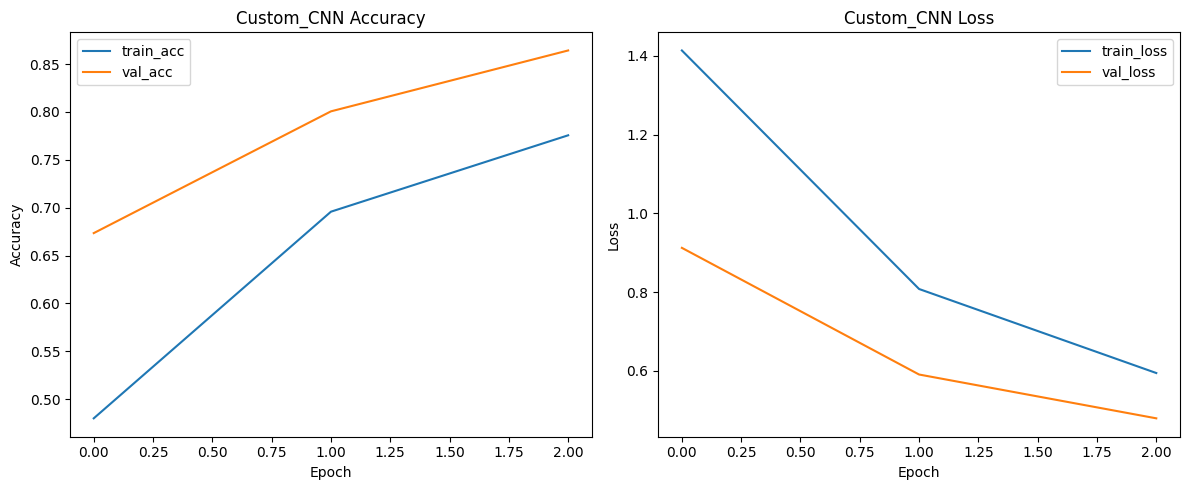

110/110 ━━━━━━━━━━━━━━━━━━━━ 1425s 13s/step - accuracy: 0.8510 - loss: 0.7126
Test loss: 0.5739 | Test accuracy: 0.8702
110/110 ━━━━━━━━━━━━━━━━━━━━ 16s 138ms/step

Classification Report:

                                  precision    recall  f1-score   support

                     animal fish       0.76      0.91      0.83       520
                animal fish bass       0.78      0.46      0.58       284
   fish sea_food black_sea_sprat       0.88      0.99      0.93       298
   fish sea_food gilt_head_bream       0.76      0.89      0.82       305
   fish sea_food hourse_mackerel       0.90      0.91      0.90       298
        fish sea_food red_mullet       0.92      1.00      0.96       291
     fish sea_food red_sea_bream       0.91      0.82      0.86       273
          fish sea_food sea_bass       0.91      0.74      0.82       327
            fish sea_food shrimp       0.97      0.99      0.98       309
fish sea_food striped_red_mullet       0.92      0.90      0.91       

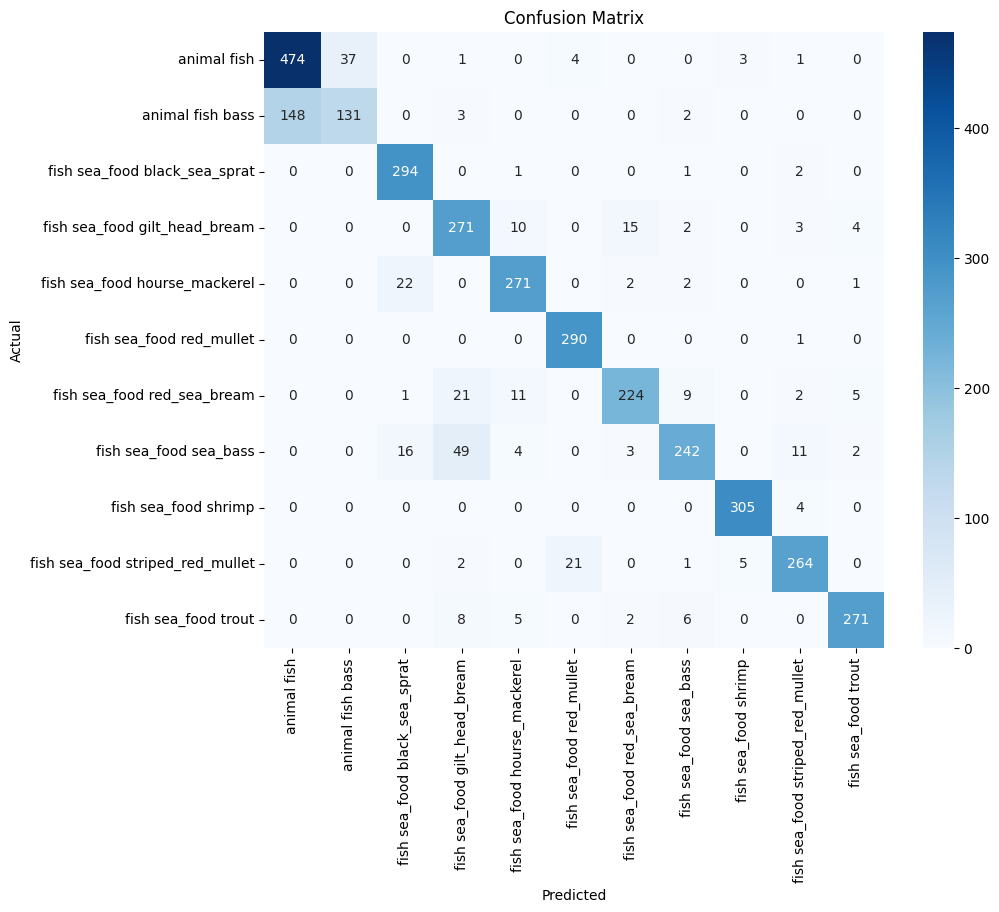

{'loss': 0.5739234089851379, 'accuracy': 0.8702005743980408}

In [ ]:
num_classes = train_gen.num_classes
cnn = create_custom_cnn((IMG_SIZE[0], IMG_SIZE[1], 3), num_classes)
history_cnn, cnn_path = train_model_and_save(cnn, "custom_cnn", train_gen, val_gen, epochs=3, patience=1, lr=1e-3)
plot_training(history_cnn, "Custom_CNN")

# Load best and evaluate on test
best_cnn = load_model(cnn_path)
evaluate_and_report(best_cnn, test_gen, train_gen.class_indices)

# Fine-tuning

/usr/local/lib/python3.12/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Loaded model: /content/drive/MyDrive/fish_models/custom_cnn.h5
Total layers in model: 10
0 conv2d_3 trainable: True
1 max_pooling2d_3 trainable: True
2 conv2d_4 trainable: True
3 max_pooling2d_4 trainable: True
4 conv2d_5 trainable: True
5 max_pooling2d_5 trainable: True
6 flatten_1 trainable: True
7 dropout_1 trainable: True
8 dense_2 trainable: True
9 dense_3 trainable: True

After setting trainable flags:
0 conv2d_3 trainable: False
1 max_pooling2d_3 trainable: False
2 conv2d_4 trainable: False
3 max_pooling2d_4 trainable: False
4 conv2d_5 trainable: False
5 max_pooling2d_5 trainable: False
6 flatten_1 trainable: True
7 dropout_1 trainable: True
8 dense_2 trainable: True
9 dense_3 trainable: True
Epoch 1/3
212/212 ━━━━━━━━━━━━━━━━━━━━ 0s 7s/step - accuracy: 0.8689 - loss: 0.3781
Epoch 1: val_accuracy improved from -inf to 0.89398, saving model to /content/drive/MyDrive/fish_models/custom_cnn_last4_finetuned.h5


212/212 ━━━━━━━━━━━━━━━━━━━━ 2365s 11s/step - accuracy: 0.8689 - loss: 0.3781 - val_accuracy: 0.8940 - val_loss: 0.4110 - learning_rate: 1.0000e-04
Epoch 2/3
212/212 ━━━━━━━━━━━━━━━━━━━━ 0s 583ms/step - accuracy: 0.8857 - loss: 0.3490
Epoch 2: val_accuracy improved from 0.89398 to 0.89992, saving model to /content/drive/MyDrive/fish_models/custom_cnn_last4_finetuned.h5


212/212 ━━━━━━━━━━━━━━━━━━━━ 132s 624ms/step - accuracy: 0.8857 - loss: 0.3489 - val_accuracy: 0.8999 - val_loss: 0.3820 - learning_rate: 1.0000e-04
Epoch 3/3
212/212 ━━━━━━━━━━━━━━━━━━━━ 0s 589ms/step - accuracy: 0.9008 - loss: 0.3096
Epoch 3: val_accuracy improved from 0.89992 to 0.90331, saving model to /content/drive/MyDrive/fish_models/custom_cnn_last4_finetuned.h5


212/212 ━━━━━━━━━━━━━━━━━━━━ 133s 628ms/step - accuracy: 0.9008 - loss: 0.3096 - val_accuracy: 0.9033 - val_loss: 0.3724 - learning_rate: 1.0000e-04
Restoring model weights from the end of the best epoch: 3.


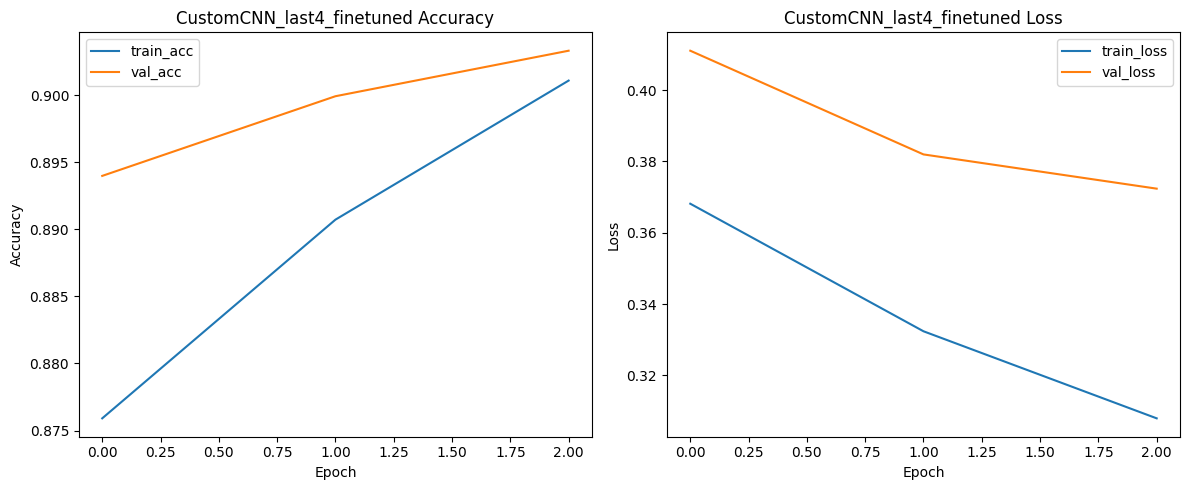


Evaluating best fine-tuned model at: /content/drive/MyDrive/fish_models/custom_cnn_last4_finetuned.h5
110/110 ━━━━━━━━━━━━━━━━━━━━ 2290s 21s/step - accuracy: 0.8669 - loss: 0.6545
Test loss: 0.4814 | Test accuracy: 0.9000
110/110 ━━━━━━━━━━━━━━━━━━━━ 15s 132ms/step

Classification Report:

                                  precision    recall  f1-score   support

                     animal fish       0.79      0.91      0.85       520
                animal fish bass       0.80      0.55      0.65       284
   fish sea_food black_sea_sprat       0.90      0.99      0.94       298
   fish sea_food gilt_head_bream       0.96      0.80      0.87       305
   fish sea_food hourse_mackerel       0.90      0.95      0.93       298
        fish sea_food red_mullet       0.98      1.00      0.99       291
     fish sea_food red_sea_bream       0.86      0.88      0.87       273
          fish sea_food sea_bass       0.91      0.85      0.88       327
            fish sea_food shrimp       0.

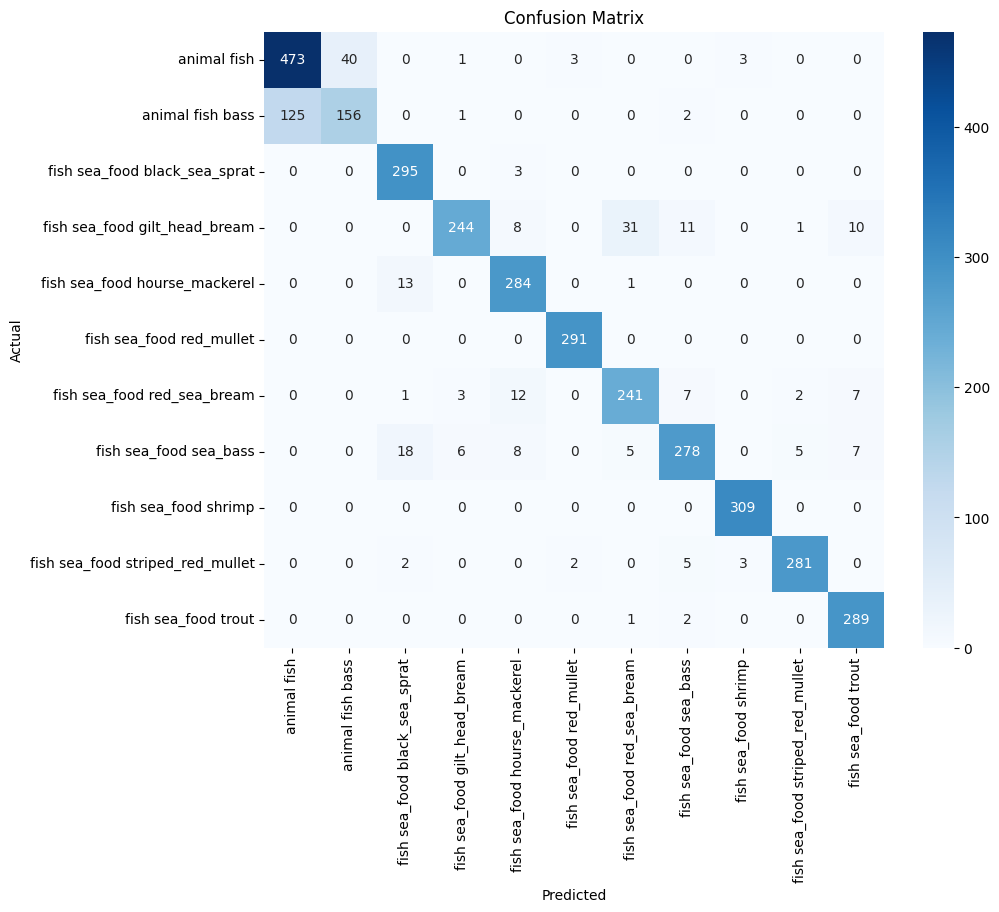

In [ ]:
# Fine-tune last 4 layers of your custom CNN with lr = 1e-5
from tensorflow.keras.models import load_model
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import ModelCheckpoint, ReduceLROnPlateau, EarlyStopping
from tensorflow.keras import backend as K
import os, gc

SAVE_DIR = '/content/drive/MyDrive/fish_models'
saved_model_name = "custom_cnn.h5"
saved_model_path = os.path.join(SAVE_DIR, saved_model_name)
unfreeze_last_n = 4          # last 4 layers will be unfrozen
finetune_epochs = 3
finetune_lr = 1e-4

# Load saved model
if not os.path.exists(saved_model_path):
    print(f"Error: Model file not found at {saved_model_path}")
    print("Please ensure the 'Train baseline custom CNN' cell (Cell 7 or similar) has been executed successfully to save the model.")
    raise FileNotFoundError(f"Model file not found: {saved_model_path}")

model = load_model(saved_model_path)
print("Loaded model:", saved_model_path)
print("Total layers in model:", len(model.layers))
for i, layer in enumerate(model.layers):
    print(i, layer.name, "trainable:", layer.trainable)

# Set trainable flags: freeze all except last `unfreeze_last_n` layers
total_layers = len(model.layers)
n = min(unfreeze_last_n, total_layers)
for layer in model.layers[:-n]:
    layer.trainable = False
for layer in model.layers[-n:]:
    layer.trainable = True

print("\nAfter setting trainable flags:")
for i, layer in enumerate(model.layers):
    print(i, layer.name, "trainable:", layer.trainable)

# Recompile with low learning rate for fine-tuning
model.compile(optimizer=Adam(learning_rate=finetune_lr),
              loss='categorical_crossentropy',
              metrics=['accuracy'])

# Callbacks
base = os.path.splitext(os.path.basename(saved_model_path))[0]
ckpt_path = os.path.join(SAVE_DIR, base + "_last4_finetuned.h5")
callbacks = [
    ModelCheckpoint(ckpt_path, monitor='val_accuracy', save_best_only=True, verbose=1, mode='max'),
    ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=1, min_lr=1e-7, verbose=1),
    EarlyStopping(monitor='val_accuracy', patience=1, restore_best_weights=True, verbose=1)
]

# Fine-tune
history_ft = model.fit(
    train_gen,
    validation_data=val_gen,
    epochs=finetune_epochs,
    callbacks=callbacks
)

# Plot training history
try:
    plot_training(history_ft, "CustomCNN_last4_finetuned")
except Exception as e:
    print("Could not call plot_training():", e)

# Evaluate best saved fine-tuned model on test set
if os.path.exists(ckpt_path):
    best_ft = load_model(ckpt_path)
    print("\nEvaluating best fine-tuned model at:", ckpt_path)
    evaluate_and_report(best_ft, test_gen, train_gen.class_indices)
else:
    print("Checkpoint not found at:", ckpt_path)
    print("Evaluating current in-memory model instead.")
    evaluate_and_report(model, test_gen, train_gen.class_indices)

# Cleanup
gc.collect()
K.clear_session()

# Random Predictions

Selected image indices: [2392, 2848, 80, 3135]


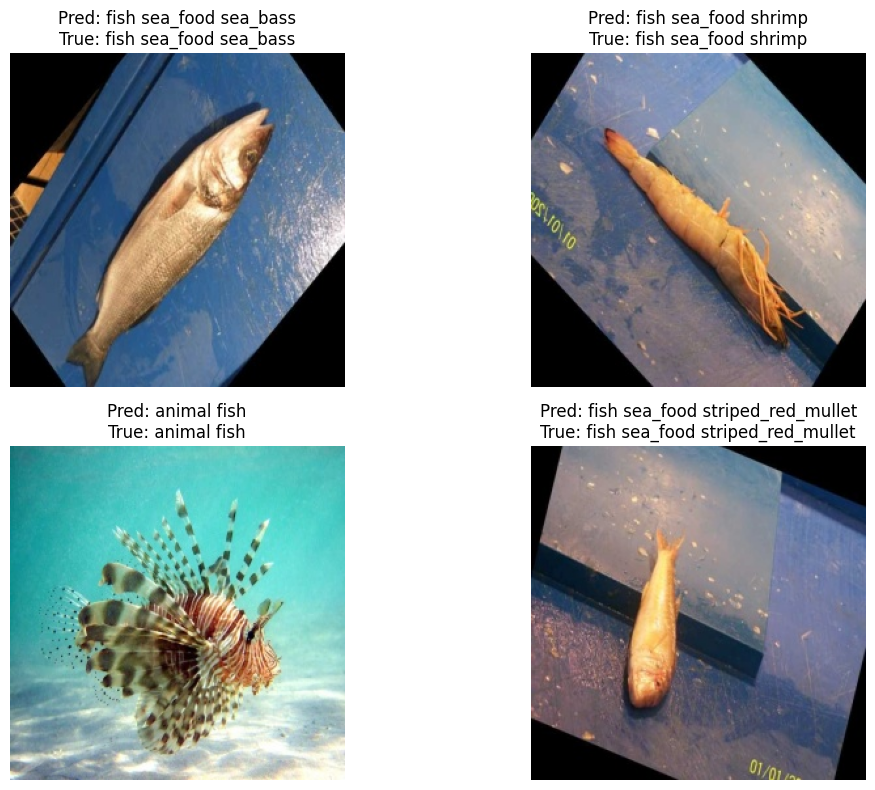

In [ ]:
import random
import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras.models import load_model
from tensorflow.keras.preprocessing import image

# Load your fine-tuned model
model_path = "/content/drive/MyDrive/fish_models/custom_cnn_last4_finetuned.h5"
model = load_model(model_path)

# Class index mapping
class_names = list(train_gen.class_indices.keys())
# Reverse mapping to get class name from integer label
idx_to_class = {v: k for k, v in train_gen.class_indices.items()}

# Pick 4 random indices from the test set
# Use test_gen.filenames to get all image paths
all_test_filenames = test_gen.filenames
indices = random.sample(range(len(all_test_filenames)), 4)
print("Selected image indices:", indices)

plt.figure(figsize=(12, 8))

for i, idx in enumerate(indices):
    # Get the filename for the selected index
    img_filename = all_test_filenames[idx]
    # Construct full path (assuming base path is TEST_DIR)
    img_path = os.path.join(TEST_DIR, img_filename)

    # Load image and resize it
    img = image.load_img(img_path, target_size=IMG_SIZE)
    img_array = image.img_to_array(img)

    # Apply the same preprocessing as val_test_datagen (rescaling)
    # val_test_datagen was defined as ImageDataGenerator(rescale=1./255)
    img_preprocessed = img_array / 255.0

    # Add a batch dimension (model expects a batch of images)
    img_batch = np.expand_dims(img_preprocessed, axis=0)

    # Predict
    pred = model.predict(img_batch, verbose=0)
    pred_class_idx = np.argmax(pred)
    pred_class = idx_to_class[pred_class_idx]

    # Get true class from filename
    true_class_name = img_filename.split(os.sep)[0] # Assuming class name is the first directory
    true_class = true_class_name

    # Show image
    plt.subplot(2, 2, i+1)
    plt.imshow(img_preprocessed)
    plt.axis("off")
    plt.title(f"Pred: {pred_class}\nTrue: {true_class}")

plt.tight_layout()
plt.show()

# Pre - Trained Model Experiment

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

import tensorflow as tf
print("TensorFlow version:", tf.__version__)
print("GPU:", tf.config.list_physical_devices('GPU'))

Mounted at /content/drive
TensorFlow version: 2.19.0
GPU: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


In [ ]:
import os, gc, json, random
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import classification_report, confusion_matrix

import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.models import Sequential, Model, load_model
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout, GlobalAveragePooling2D, Input
from tensorflow.keras.callbacks import ModelCheckpoint, EarlyStopping, ReduceLROnPlateau
from tensorflow.keras.optimizers import Adam

# Paths (change if needed)
DATA_DIR = '/content/drive/MyDrive/data/fish_dataset'
TRAIN_DIR = os.path.join(DATA_DIR, 'train')
VAL_DIR   = os.path.join(DATA_DIR, 'val')
TEST_DIR  = os.path.join(DATA_DIR, 'test')

SAVE_DIR = "/content/drive/MyDrive/fish_models"
os.makedirs(SAVE_DIR, exist_ok=True)

# Hyperparameters
IMG_SIZE = (256, 256)
BATCH_SIZE = 32
SEED = 42
EPOCHS_HEAD = 3
EPOCHS_FINETUNE = 3
PATIENCE = 1
LR_HEAD = 1e-3 # 1e-3 = 0.001
LR_FINETUNE = 1e-4 # 1e-4 = 0.0001

np.random.seed(SEED)
random.seed(SEED)
tf.random.set_seed(SEED)
print("Setup done.")


Setup done.


In [ ]:
# Backbones and correct preprocessors
from tensorflow.keras.applications import VGG16, ResNet50, MobileNet, InceptionV3, EfficientNetB0
from tensorflow.keras.applications.vgg16 import preprocess_input as vgg_pre
from tensorflow.keras.applications.resnet50 import preprocess_input as resnet_pre
from tensorflow.keras.applications.mobilenet import preprocess_input as mobilenet_pre
from tensorflow.keras.applications.inception_v3 import preprocess_input as inception_pre
from tensorflow.keras.applications.efficientnet import preprocess_input as efficientnet_pre

BACKBONES = {
    "VGG16":          {"ctor": VGG16,         "unfreeze": -8,  "pre": vgg_pre},
    "ResNet50":       {"ctor": ResNet50,      "unfreeze": -50, "pre": resnet_pre},
    "MobileNet":      {"ctor": MobileNet,     "unfreeze": -30, "pre": mobilenet_pre},
    "InceptionV3":    {"ctor": InceptionV3,   "unfreeze": -50, "pre": inception_pre},
    "EfficientNetB0": {"ctor": EfficientNetB0,"unfreeze": -30, "pre": efficientnet_pre},
}
print("Backbones configured.")


Backbones configured.


In [ ]:
# function to build ImageDataGenerators for a given backbone (applies correct preprocess_input)
def build_gens(preprocess_fn):
    train_datagen = ImageDataGenerator(
        preprocessing_function=preprocess_fn,
        rotation_range=20,
        zoom_range=0.2,
        horizontal_flip=True,
        width_shift_range=0.1,
        height_shift_range=0.1,
        shear_range=0.1,
        fill_mode='nearest'
    )

    val_test_datagen = ImageDataGenerator(preprocessing_function=preprocess_fn)

    train_gen = train_datagen.flow_from_directory(
        TRAIN_DIR,
        target_size=IMG_SIZE,
        batch_size=BATCH_SIZE,
        class_mode='categorical',
        shuffle=True,
        seed=SEED,
        color_mode='rgb'
    )

    val_gen = val_test_datagen.flow_from_directory(
        VAL_DIR,
        target_size=IMG_SIZE,
        batch_size=BATCH_SIZE,
        class_mode='categorical',
        shuffle=False,
        color_mode='rgb'
    )

    test_gen = val_test_datagen.flow_from_directory(
        TEST_DIR,
        target_size=IMG_SIZE,
        batch_size=BATCH_SIZE,
        class_mode='categorical',
        shuffle=False,
        color_mode='rgb'
    )

    return train_gen, val_gen, test_gen


# Quick check (build gens for one backbone to ensure paths exist)
_example_pre = BACKBONES["VGG16"]["pre"]
tg, vg, tg_test = build_gens(_example_pre)
print("Classes:", tg.class_indices)

with open(os.path.join(SAVE_DIR, "class_indices.json"), "w") as f:
    json.dump(tg.class_indices, f, indent=2)

Found 6753 images belonging to 11 classes.
Found 1179 images belonging to 11 classes.
Found 3490 images belonging to 11 classes.
Classes: {'animal fish': 0, 'animal fish bass': 1, 'fish sea_food black_sea_sprat': 2, 'fish sea_food gilt_head_bream': 3, 'fish sea_food hourse_mackerel': 4, 'fish sea_food red_mullet': 5, 'fish sea_food red_sea_bream': 6, 'fish sea_food sea_bass': 7, 'fish sea_food shrimp': 8, 'fish sea_food striped_red_mullet': 9, 'fish sea_food trout': 10}


# Plotting training history, evaluation and transfer model

In [ ]:
def plot_training(history, model_name):
    if history is None:
        print("No history to plot.")
        return
    plt.figure(figsize=(12,5))
    plt.subplot(1,2,1)
    plt.plot(history.history.get('accuracy',[]), label='train')
    plt.plot(history.history.get('val_accuracy',[]), label='val')
    plt.title(f"{model_name} Accuracy"); plt.legend()
    plt.subplot(1,2,2)
    plt.plot(history.history.get('loss',[]), label='train')
    plt.plot(history.history.get('val_loss',[]), label='val')
    plt.title(f"{model_name} Loss"); plt.legend()
    plt.tight_layout()
    plt.savefig(os.path.join(SAVE_DIR, f"{model_name}.png"))
    plt.show()

def evaluate_and_report(model, generator, class_indices):
    print("Evaluating...")
    loss, acc = model.evaluate(generator, verbose=1)
    preds = model.predict(generator)
    y_pred = np.argmax(preds, axis=1)
    y_true = generator.classes
    class_names = list(class_indices.keys())
    print("\nClassification Report:\n")
    print(classification_report(y_true, y_pred, target_names=class_names))
    cm = confusion_matrix(y_true, y_pred)
    plt.figure(figsize=(10,8))
    sns.heatmap(cm, annot=True, fmt='d', xticklabels=class_names, yticklabels=class_names)
    plt.title("Confusion Matrix")
    plt.show()
    return {"loss": loss, "accuracy": acc}

def create_transfer_model(base_model, num_classes, dropout=0.5):
    base_model.trainable = False
    x = base_model.output
    x = GlobalAveragePooling2D()(x)
    x = Dropout(dropout)(x)
    x = Dense(128, activation="relu")(x)
    output = Dense(num_classes, activation="softmax")(x)
    return Model(inputs=base_model.input, outputs=output)

# Training head



=== Training HEAD for VGG16 ===
Found 6753 images belonging to 11 classes.
Found 1179 images belonging to 11 classes.
Found 3490 images belonging to 11 classes.
58889256/58889256 ━━━━━━━━━━━━━━━━━━━━ 4s 0us/step
[TRAIN] will save head to: /content/drive/MyDrive/fish_models/VGG16_head.h5


/usr/local/lib/python3.12/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/3
212/212 ━━━━━━━━━━━━━━━━━━━━ 0s 21s/step - accuracy: 0.4225 - loss: 3.1618 
Epoch 1: val_accuracy improved from -inf to 0.95759, saving model to /content/drive/MyDrive/fish_models/VGG16_head.h5


212/212 ━━━━━━━━━━━━━━━━━━━━ 5266s 25s/step - accuracy: 0.4233 - loss: 3.1549 - val_accuracy: 0.9576 - val_loss: 0.1642
Epoch 2/3
212/212 ━━━━━━━━━━━━━━━━━━━━ 0s 624ms/step - accuracy: 0.8209 - loss: 0.5193
Epoch 2: val_accuracy improved from 0.95759 to 0.98219, saving model to /content/drive/MyDrive/fish_models/VGG16_head.h5


212/212 ━━━━━━━━━━━━━━━━━━━━ 144s 677ms/step - accuracy: 0.8210 - loss: 0.5191 - val_accuracy: 0.9822 - val_loss: 0.0747
Epoch 3/3
212/212 ━━━━━━━━━━━━━━━━━━━━ 0s 620ms/step - accuracy: 0.8753 - loss: 0.3450
Epoch 3: val_accuracy improved from 0.98219 to 0.98728, saving model to /content/drive/MyDrive/fish_models/VGG16_head.h5


212/212 ━━━━━━━━━━━━━━━━━━━━ 144s 679ms/step - accuracy: 0.8753 - loss: 0.3449 - val_accuracy: 0.9873 - val_loss: 0.0461
Restoring model weights from the end of the best epoch: 3.


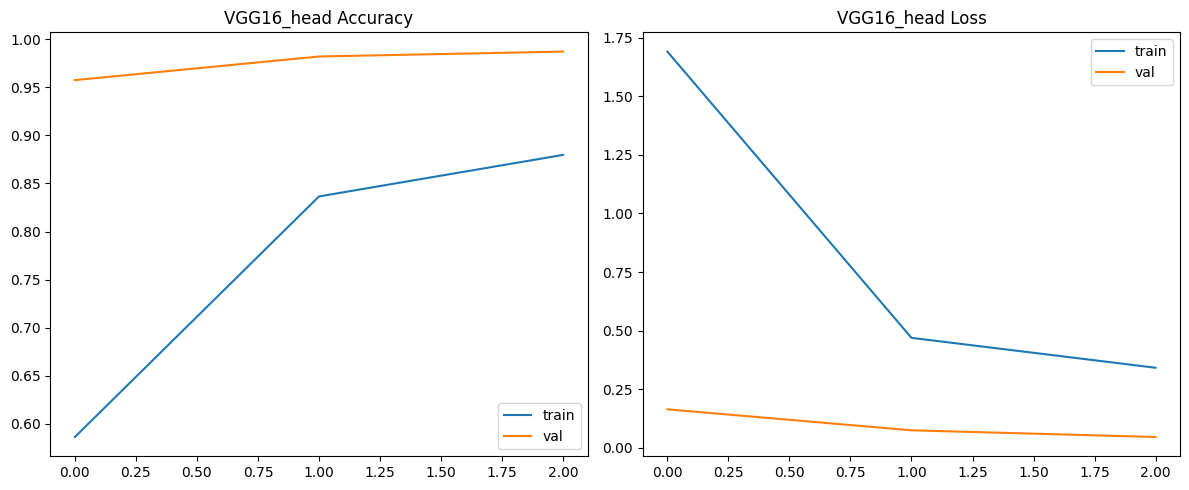

[DONE] VGG16 head saved at: /content/drive/MyDrive/fish_models/VGG16_head.h5
[SAVED] class indices -> /content/drive/MyDrive/fish_models/VGG16_class_indices.json


=== Training HEAD for ResNet50 ===
Found 6753 images belonging to 11 classes.
Found 1179 images belonging to 11 classes.
Found 3490 images belonging to 11 classes.
94765736/94765736 ━━━━━━━━━━━━━━━━━━━━ 5s 0us/step
[TRAIN] will save head to: /content/drive/MyDrive/fish_models/ResNet50_head.h5
Epoch 1/3
212/212 ━━━━━━━━━━━━━━━━━━━━ 0s 586ms/step - accuracy: 0.7198 - loss: 0.8691
Epoch 1: val_accuracy improved from -inf to 0.99237, saving model to /content/drive/MyDrive/fish_models/ResNet50_head.h5


212/212 ━━━━━━━━━━━━━━━━━━━━ 153s 662ms/step - accuracy: 0.7205 - loss: 0.8669 - val_accuracy: 0.9924 - val_loss: 0.0285
Epoch 2/3
212/212 ━━━━━━━━━━━━━━━━━━━━ 0s 588ms/step - accuracy: 0.9613 - loss: 0.1160
Epoch 2: val_accuracy did not improve from 0.99237
212/212 ━━━━━━━━━━━━━━━━━━━━ 131s 616ms/step - accuracy: 0.9613 - loss: 0.1159 - val_accuracy: 0.9915 - val_loss: 0.0247
Epoch 2: early stopping
Restoring model weights from the end of the best epoch: 1.


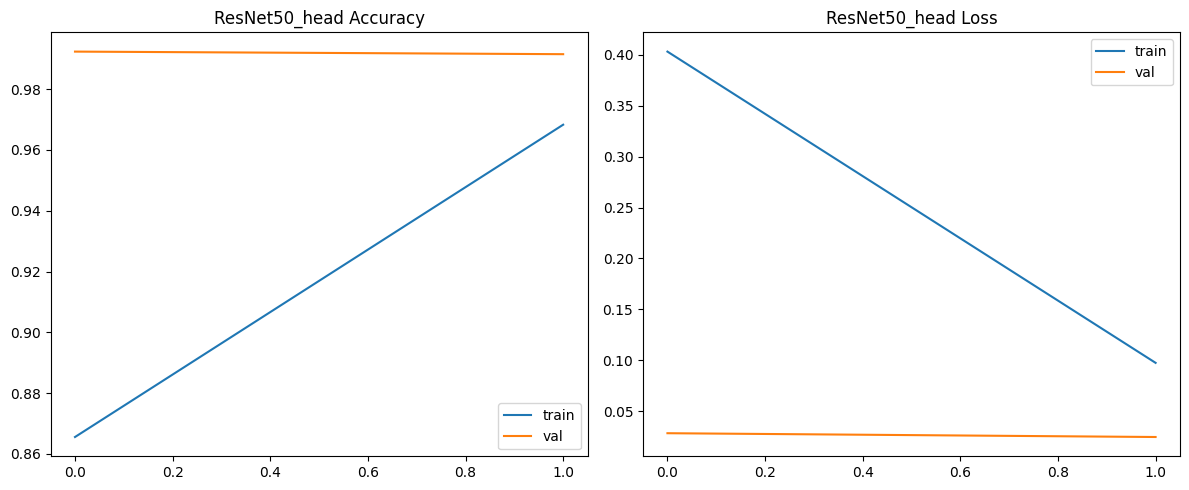

[DONE] ResNet50 head saved at: /content/drive/MyDrive/fish_models/ResNet50_head.h5
[SAVED] class indices -> /content/drive/MyDrive/fish_models/ResNet50_class_indices.json


=== Training HEAD for MobileNet ===
Found 6753 images belonging to 11 classes.
Found 1179 images belonging to 11 classes.
Found 3490 images belonging to 11 classes.


/tmp/ipython-input-1868003874.py:58: UserWarning: `input_shape` is undefined or non-square, or `rows` is not in [128, 160, 192, 224]. Weights for input shape (224, 224) will be loaded as the default.
  base = cfg["ctor"](weights='imagenet', include_top=False, input_shape=(IMG_SIZE[0], IMG_SIZE[1], 3))


17225924/17225924 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step
[TRAIN] will save head to: /content/drive/MyDrive/fish_models/MobileNet_head.h5
Epoch 1/3
212/212 ━━━━━━━━━━━━━━━━━━━━ 0s 600ms/step - accuracy: 0.5820 - loss: 1.2718
Epoch 1: val_accuracy improved from -inf to 0.97795, saving model to /content/drive/MyDrive/fish_models/MobileNet_head.h5


212/212 ━━━━━━━━━━━━━━━━━━━━ 161s 694ms/step - accuracy: 0.5829 - loss: 1.2691 - val_accuracy: 0.9779 - val_loss: 0.0792
Epoch 2/3
212/212 ━━━━━━━━━━━━━━━━━━━━ 0s 566ms/step - accuracy: 0.9308 - loss: 0.1955
Epoch 2: val_accuracy improved from 0.97795 to 0.98473, saving model to /content/drive/MyDrive/fish_models/MobileNet_head.h5


212/212 ━━━━━━━━━━━━━━━━━━━━ 126s 593ms/step - accuracy: 0.9308 - loss: 0.1955 - val_accuracy: 0.9847 - val_loss: 0.0489
Epoch 3/3
212/212 ━━━━━━━━━━━━━━━━━━━━ 0s 556ms/step - accuracy: 0.9495 - loss: 0.1493
Epoch 3: val_accuracy improved from 0.98473 to 0.99321, saving model to /content/drive/MyDrive/fish_models/MobileNet_head.h5


212/212 ━━━━━━━━━━━━━━━━━━━━ 125s 587ms/step - accuracy: 0.9495 - loss: 0.1493 - val_accuracy: 0.9932 - val_loss: 0.0378
Restoring model weights from the end of the best epoch: 3.


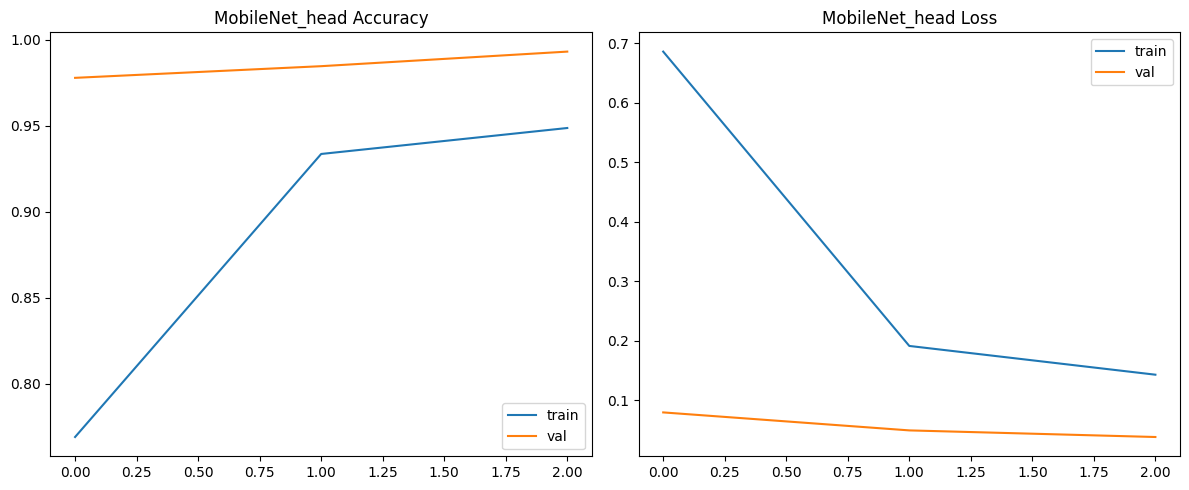

[DONE] MobileNet head saved at: /content/drive/MyDrive/fish_models/MobileNet_head.h5
[SAVED] class indices -> /content/drive/MyDrive/fish_models/MobileNet_class_indices.json


=== Training HEAD for InceptionV3 ===
Found 6753 images belonging to 11 classes.
Found 1179 images belonging to 11 classes.
Found 3490 images belonging to 11 classes.
87910968/87910968 ━━━━━━━━━━━━━━━━━━━━ 5s 0us/step
[TRAIN] will save head to: /content/drive/MyDrive/fish_models/InceptionV3_head.h5
Epoch 1/3
212/212 ━━━━━━━━━━━━━━━━━━━━ 0s 610ms/step - accuracy: 0.6340 - loss: 1.0932
Epoch 1: val_accuracy improved from -inf to 0.93723, saving model to /content/drive/MyDrive/fish_models/InceptionV3_head.h5


212/212 ━━━━━━━━━━━━━━━━━━━━ 167s 707ms/step - accuracy: 0.6347 - loss: 1.0910 - val_accuracy: 0.9372 - val_loss: 0.1821
Epoch 2/3
212/212 ━━━━━━━━━━━━━━━━━━━━ 0s 587ms/step - accuracy: 0.8954 - loss: 0.2934
Epoch 2: val_accuracy improved from 0.93723 to 0.96098, saving model to /content/drive/MyDrive/fish_models/InceptionV3_head.h5


212/212 ━━━━━━━━━━━━━━━━━━━━ 134s 633ms/step - accuracy: 0.8954 - loss: 0.2933 - val_accuracy: 0.9610 - val_loss: 0.1136
Epoch 3/3
212/212 ━━━━━━━━━━━━━━━━━━━━ 0s 580ms/step - accuracy: 0.9203 - loss: 0.2171
Epoch 3: val_accuracy improved from 0.96098 to 0.96947, saving model to /content/drive/MyDrive/fish_models/InceptionV3_head.h5


212/212 ━━━━━━━━━━━━━━━━━━━━ 131s 618ms/step - accuracy: 0.9203 - loss: 0.2170 - val_accuracy: 0.9695 - val_loss: 0.0922
Restoring model weights from the end of the best epoch: 3.


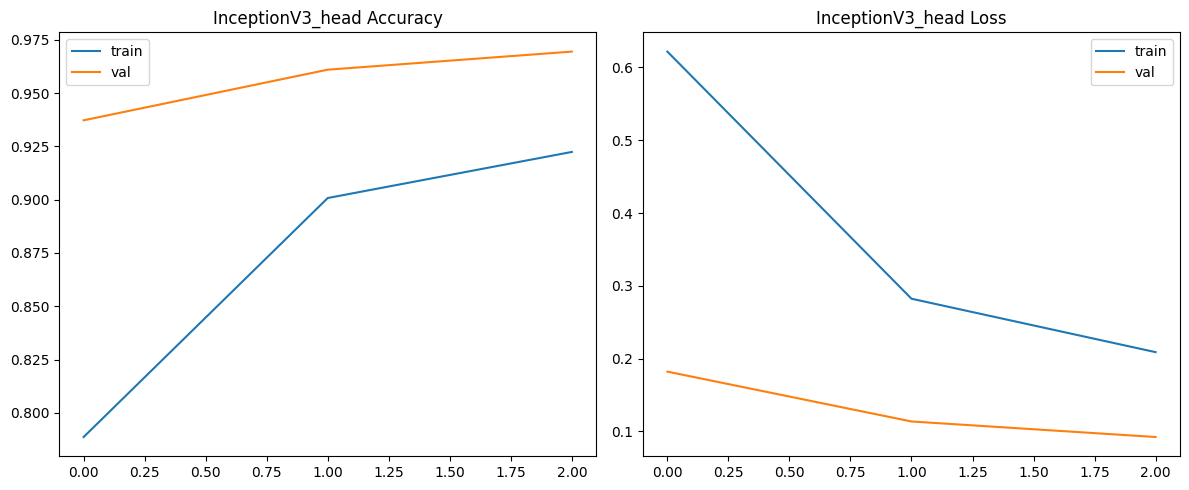

[DONE] InceptionV3 head saved at: /content/drive/MyDrive/fish_models/InceptionV3_head.h5
[SAVED] class indices -> /content/drive/MyDrive/fish_models/InceptionV3_class_indices.json


=== Training HEAD for EfficientNetB0 ===
Found 6753 images belonging to 11 classes.
Found 1179 images belonging to 11 classes.
Found 3490 images belonging to 11 classes.
16705208/16705208 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step
[TRAIN] (EfficientNet) will save head to: /content/drive/MyDrive/fish_models/EfficientNetB0_head.keras
Epoch 1/3
212/212 ━━━━━━━━━━━━━━━━━━━━ 0s 623ms/step - accuracy: 0.7354 - loss: 0.8555
Epoch 1: val_accuracy improved from -inf to 0.99152, saving model to /content/drive/MyDrive/fish_models/EfficientNetB0_head.keras
212/212 ━━━━━━━━━━━━━━━━━━━━ 182s 736ms/step - accuracy: 0.7361 - loss: 0.8534 - val_accuracy: 0.9915 - val_loss: 0.0468
Epoch 2/3
212/212 ━━━━━━━━━━━━━━━━━━━━ 0s 558ms/step - accuracy: 0.9736 - loss: 0.0944
Epoch 2: val_accuracy improved from 0.99152 to 0.99406, saving model 

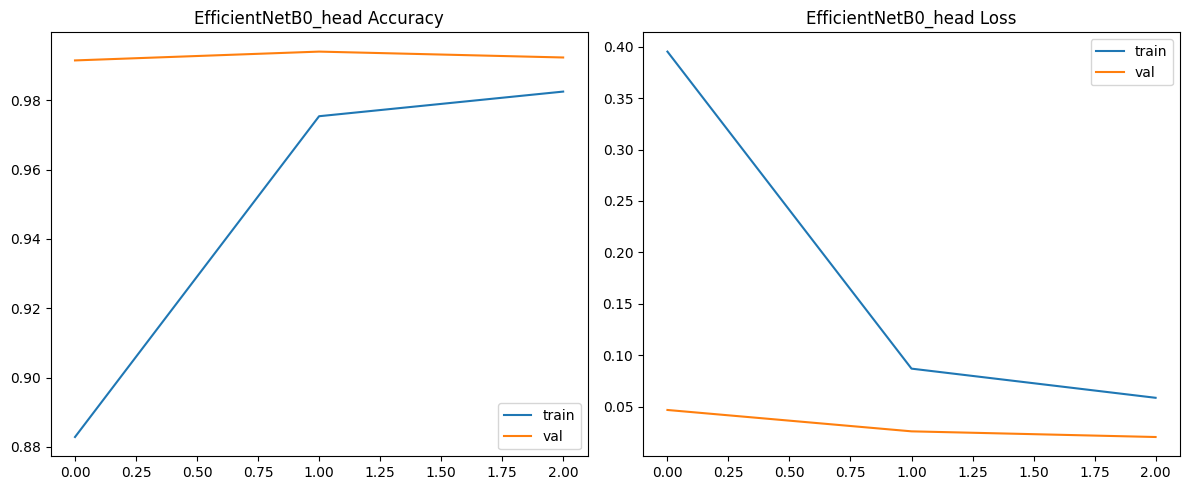

[DONE] EfficientNetB0 head saved at: /content/drive/MyDrive/fish_models/EfficientNetB0_head.keras
[SAVED] class indices -> /content/drive/MyDrive/fish_models/EfficientNetB0_class_indices.json


In [ ]:
# training head function and run heads for all backbones
from tensorflow.keras.callbacks import ModelCheckpoint, EarlyStopping
from tensorflow.keras.optimizers import Adam
import traceback

def train_model_and_save(model, name, train_gen, val_gen, epochs=EPOCHS_HEAD, patience=PATIENCE, lr=LR_HEAD):

    model.compile(optimizer=Adam(learning_rate=lr), loss="categorical_crossentropy", metrics=["accuracy"])

    # Decide save extension based on model name (prefer name contains 'efficientnet')
    is_efficientnet = "efficientnet" in name.lower() or "efficientnet" in model.__class__.__name__.lower()
    base_ckpt_h5 = os.path.join(SAVE_DIR, f"{name}.h5")
    base_ckpt_keras = os.path.join(SAVE_DIR, f"{name}.keras")

    try:
        if is_efficientnet:
            # Save native keras format (safe for EfficientNet)
            ckpt_path = base_ckpt_keras
            ckpt = ModelCheckpoint(ckpt_path, monitor='val_accuracy', save_best_only=True, verbose=1)
            print(f"[TRAIN] (EfficientNet) will save head to: {ckpt_path}")
        else:
            ckpt_path = base_ckpt_h5
            ckpt = ModelCheckpoint(ckpt_path, monitor='val_accuracy', save_best_only=True, verbose=1)
            print(f"[TRAIN] will save head to: {ckpt_path}")

        early = EarlyStopping(monitor='val_accuracy', patience=patience, restore_best_weights=True, verbose=1)

        history = model.fit(train_gen, validation_data=val_gen, epochs=epochs, callbacks=[ckpt, early])
        return history, ckpt_path

    except Exception as e:
        print("Exception during head training/saving. Attempting fallback save (.keras).")
        traceback.print_exc()
        # fallback: save full model as native .keras
        fallback_path = base_ckpt_keras
        try:
            model.save(fallback_path)
            print(f"[FALLBACK] Saved head model to: {fallback_path}")
            return None, fallback_path
        except Exception as e2:
            print("Fallback save also failed. Raising error.")
            traceback.print_exc()
            raise

# Run head training for each backbone (uses correct preprocess via build_gens)
head_paths = {}
for name, cfg in BACKBONES.items():
    print(f"\n\n=== Training HEAD for {name} ===")
    # build gens with correct preprocessing for this backbone
    train_gen, val_gen, test_gen = build_gens(cfg["pre"])

    # build base + head
    base = cfg["ctor"](weights='imagenet', include_top=False, input_shape=(IMG_SIZE[0], IMG_SIZE[1], 3))
    model = create_transfer_model(base, train_gen.num_classes)

    # train & save
    history, path = train_model_and_save(model, f"{name}_head", train_gen, val_gen,
                                         epochs=EPOCHS_HEAD, patience=PATIENCE, lr=LR_HEAD)

    # Plot if history
    if history is not None:
        plot_training(history, f"{name}_head")
    else:
        print(f"[INFO] No training history returned for {name}_head (fallback save may have been used).")

    # record path (fallback or normal)
    head_paths[name] = path
    print(f"[DONE] {name} head saved at: {path}")

    # save generator/class indices for later (canonical mapping)
    try:
        ci_path = os.path.join(SAVE_DIR, f"{name}_class_indices.json")
        with open(ci_path, "w") as f:
            json.dump(train_gen.class_indices, f, indent=2)
        print(f"[SAVED] class indices -> {ci_path}")
    except Exception as e
        print("[WARN] Could not save class indices:", e)

    gc.collect()

# Evaluation


===== EVALUATING ALL HEAD MODELS (DIRECT FROM DRIVE) =====


=== Evaluating HEAD model: VGG16 ===
Loading model: /content/drive/MyDrive/fish_models/VGG16_head.h5


Model loaded successfully.
Found 6753 images belonging to 11 classes.
Found 1179 images belonging to 11 classes.
Found 3458 images belonging to 11 classes.
Loaded class indices from: /content/drive/MyDrive/fish_models/VGG16_class_indices.json
Evaluating...


/usr/local/lib/python3.12/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


109/109 ━━━━━━━━━━━━━━━━━━━━ 1016s 9s/step - accuracy: 0.9743 - loss: 0.0836
109/109 ━━━━━━━━━━━━━━━━━━━━ 26s 228ms/step

Classification Report:

                                  precision    recall  f1-score   support

                     animal fish       0.94      0.99      0.96       520
                animal fish bass       0.98      0.88      0.93       284
   fish sea_food black_sea_sprat       0.98      1.00      0.99       298
   fish sea_food gilt_head_bream       0.96      0.99      0.98       305
   fish sea_food hourse_mackerel       1.00      0.99      0.99       286
        fish sea_food red_mullet       0.99      1.00      0.99       291
     fish sea_food red_sea_bream       0.99      0.99      0.99       273
          fish sea_food sea_bass       1.00      0.97      0.98       327
            fish sea_food shrimp       0.93      1.00      0.96       289
fish sea_food striped_red_mullet       1.00      0.92      0.96       293
             fish sea_food trout       

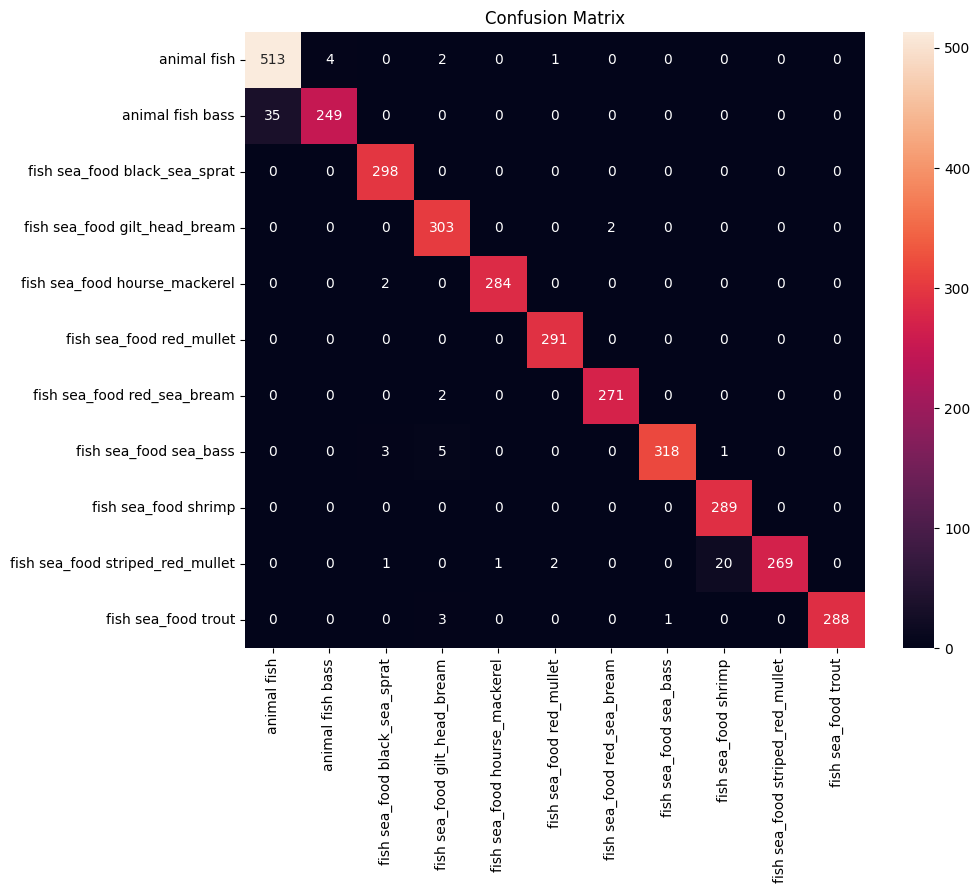



=== Evaluating HEAD model: ResNet50 ===
Loading model: /content/drive/MyDrive/fish_models/ResNet50_head.h5


Model loaded successfully.
Found 6753 images belonging to 11 classes.
Found 1179 images belonging to 11 classes.
Found 3458 images belonging to 11 classes.
Loaded class indices from: /content/drive/MyDrive/fish_models/ResNet50_class_indices.json
Evaluating...


/usr/local/lib/python3.12/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


109/109 ━━━━━━━━━━━━━━━━━━━━ 30s 189ms/step - accuracy: 0.9773 - loss: 0.0597
109/109 ━━━━━━━━━━━━━━━━━━━━ 26s 203ms/step

Classification Report:

                                  precision    recall  f1-score   support

                     animal fish       0.94      1.00      0.96       520
                animal fish bass       1.00      0.87      0.93       284
   fish sea_food black_sea_sprat       1.00      1.00      1.00       298
   fish sea_food gilt_head_bream       1.00      0.97      0.99       305
   fish sea_food hourse_mackerel       0.99      0.99      0.99       286
        fish sea_food red_mullet       1.00      0.98      0.99       291
     fish sea_food red_sea_bream       0.99      1.00      0.99       273
          fish sea_food sea_bass       1.00      1.00      1.00       327
            fish sea_food shrimp       1.00      1.00      1.00       289
fish sea_food striped_red_mullet       0.97      1.00      0.98       293
             fish sea_food trout      

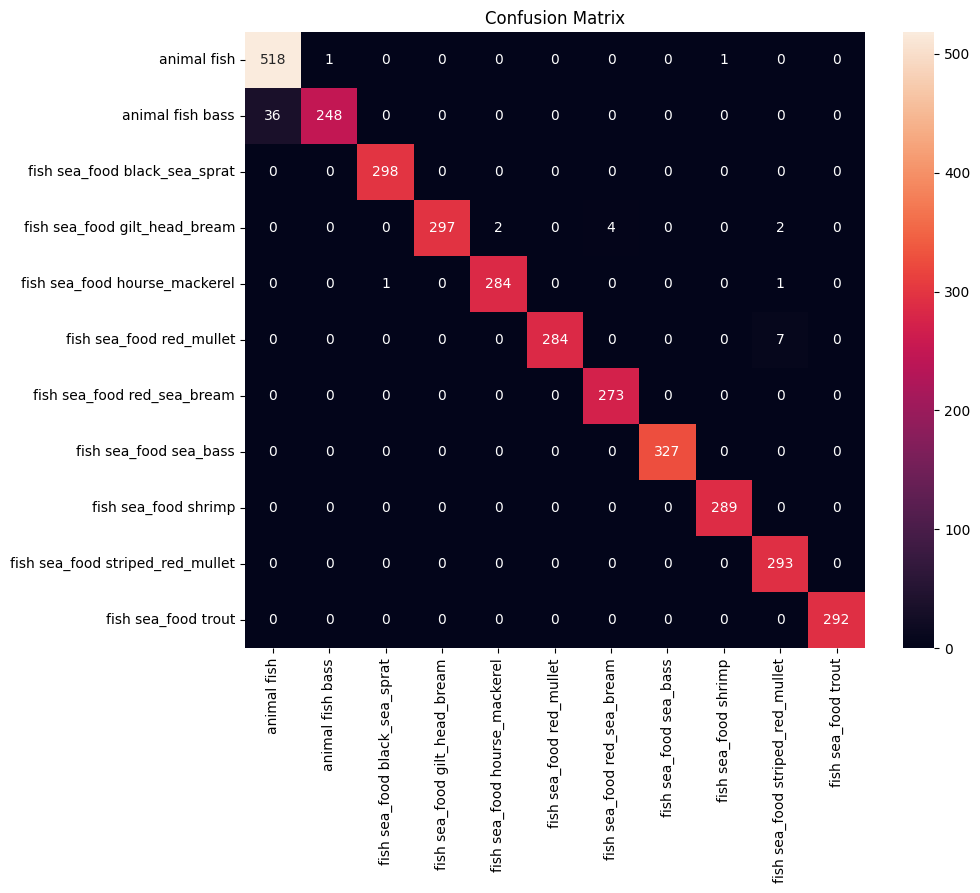



=== Evaluating HEAD model: MobileNet ===
Loading model: /content/drive/MyDrive/fish_models/MobileNet_head.h5


Model loaded successfully.
Found 6753 images belonging to 11 classes.
Found 1179 images belonging to 11 classes.
Found 3458 images belonging to 11 classes.
Loaded class indices from: /content/drive/MyDrive/fish_models/MobileNet_class_indices.json
Evaluating...


/usr/local/lib/python3.12/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


109/109 ━━━━━━━━━━━━━━━━━━━━ 37s 225ms/step - accuracy: 0.9916 - loss: 0.0298
109/109 ━━━━━━━━━━━━━━━━━━━━ 22s 170ms/step

Classification Report:

                                  precision    recall  f1-score   support

                     animal fish       0.99      0.98      0.99       520
                animal fish bass       0.98      0.99      0.98       284
   fish sea_food black_sea_sprat       0.99      1.00      1.00       298
   fish sea_food gilt_head_bream       1.00      1.00      1.00       305
   fish sea_food hourse_mackerel       0.99      1.00      0.99       286
        fish sea_food red_mullet       0.98      1.00      0.99       291
     fish sea_food red_sea_bream       1.00      1.00      1.00       273
          fish sea_food sea_bass       0.98      1.00      0.99       327
            fish sea_food shrimp       1.00      1.00      1.00       289
fish sea_food striped_red_mullet       1.00      0.95      0.97       293
             fish sea_food trout      

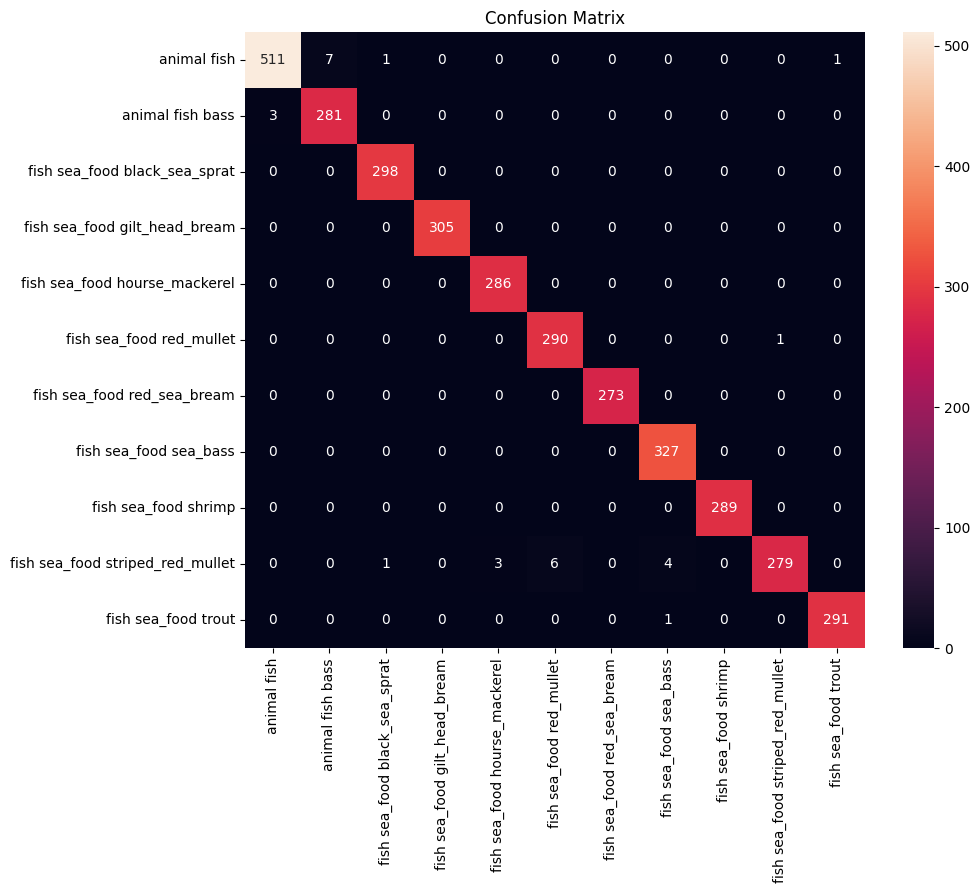



=== Evaluating HEAD model: InceptionV3 ===
Loading model: /content/drive/MyDrive/fish_models/InceptionV3_head.h5


Model loaded successfully.
Found 6753 images belonging to 11 classes.
Found 1179 images belonging to 11 classes.
Found 3458 images belonging to 11 classes.
Loaded class indices from: /content/drive/MyDrive/fish_models/InceptionV3_class_indices.json
Evaluating...


/usr/local/lib/python3.12/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


109/109 ━━━━━━━━━━━━━━━━━━━━ 35s 209ms/step - accuracy: 0.9607 - loss: 0.1674
109/109 ━━━━━━━━━━━━━━━━━━━━ 29s 196ms/step

Classification Report:

                                  precision    recall  f1-score   support

                     animal fish       0.92      0.98      0.95       520
                animal fish bass       0.98      0.83      0.90       284
   fish sea_food black_sea_sprat       0.99      0.99      0.99       298
   fish sea_food gilt_head_bream       0.95      0.99      0.97       305
   fish sea_food hourse_mackerel       0.97      1.00      0.98       286
        fish sea_food red_mullet       1.00      0.98      0.99       291
     fish sea_food red_sea_bream       0.99      1.00      0.99       273
          fish sea_food sea_bass       0.99      0.94      0.96       327
            fish sea_food shrimp       1.00      1.00      1.00       289
fish sea_food striped_red_mullet       0.97      0.98      0.97       293
             fish sea_food trout      

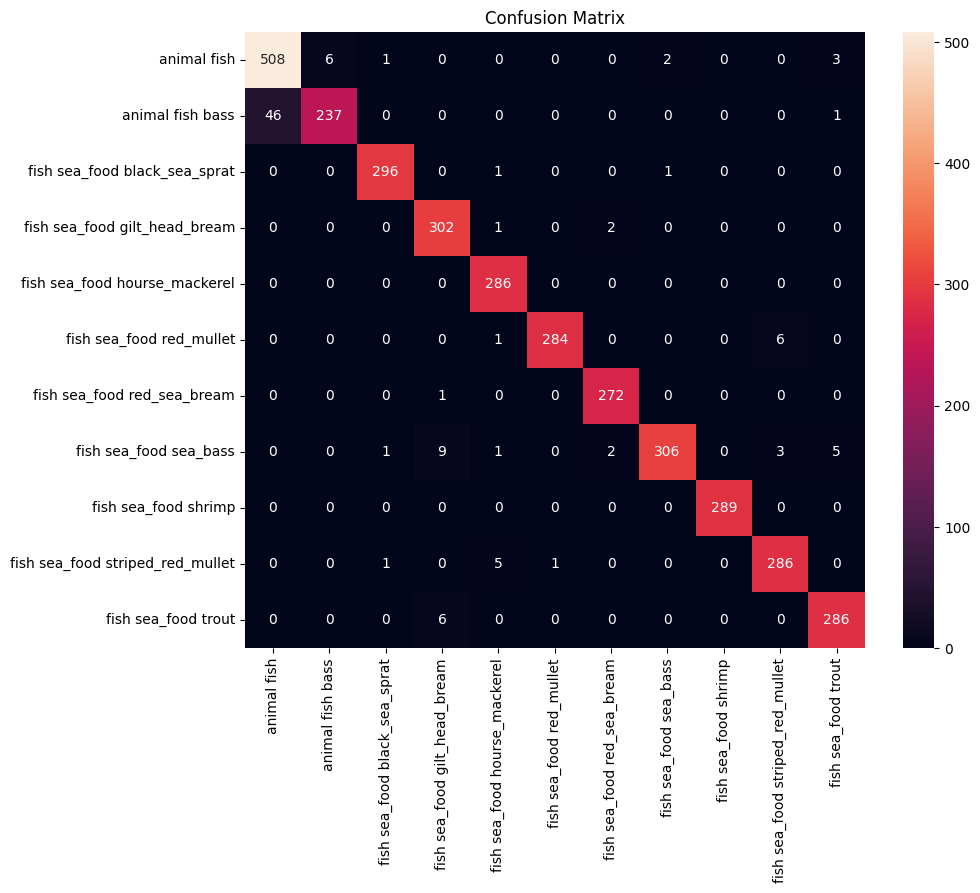



=== Evaluating HEAD model: EfficientNetB0 ===
Loading model: /content/drive/MyDrive/fish_models/EfficientNetB0_head.keras
Model loaded successfully.
Found 6753 images belonging to 11 classes.
Found 1179 images belonging to 11 classes.
Found 3458 images belonging to 11 classes.
Loaded class indices from: /content/drive/MyDrive/fish_models/EfficientNetB0_class_indices.json
Evaluating...


/usr/local/lib/python3.12/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


109/109 ━━━━━━━━━━━━━━━━━━━━ 40s 230ms/step - accuracy: 0.9792 - loss: 0.0705
109/109 ━━━━━━━━━━━━━━━━━━━━ 29s 205ms/step

Classification Report:

                                  precision    recall  f1-score   support

                     animal fish       0.95      0.98      0.97       520
                animal fish bass       0.98      0.91      0.95       284
   fish sea_food black_sea_sprat       1.00      1.00      1.00       298
   fish sea_food gilt_head_bream       0.99      1.00      1.00       305
   fish sea_food hourse_mackerel       1.00      1.00      1.00       286
        fish sea_food red_mullet       1.00      1.00      1.00       291
     fish sea_food red_sea_bream       1.00      1.00      1.00       273
          fish sea_food sea_bass       1.00      1.00      1.00       327
            fish sea_food shrimp       1.00      1.00      1.00       289
fish sea_food striped_red_mullet       1.00      1.00      1.00       293
             fish sea_food trout      

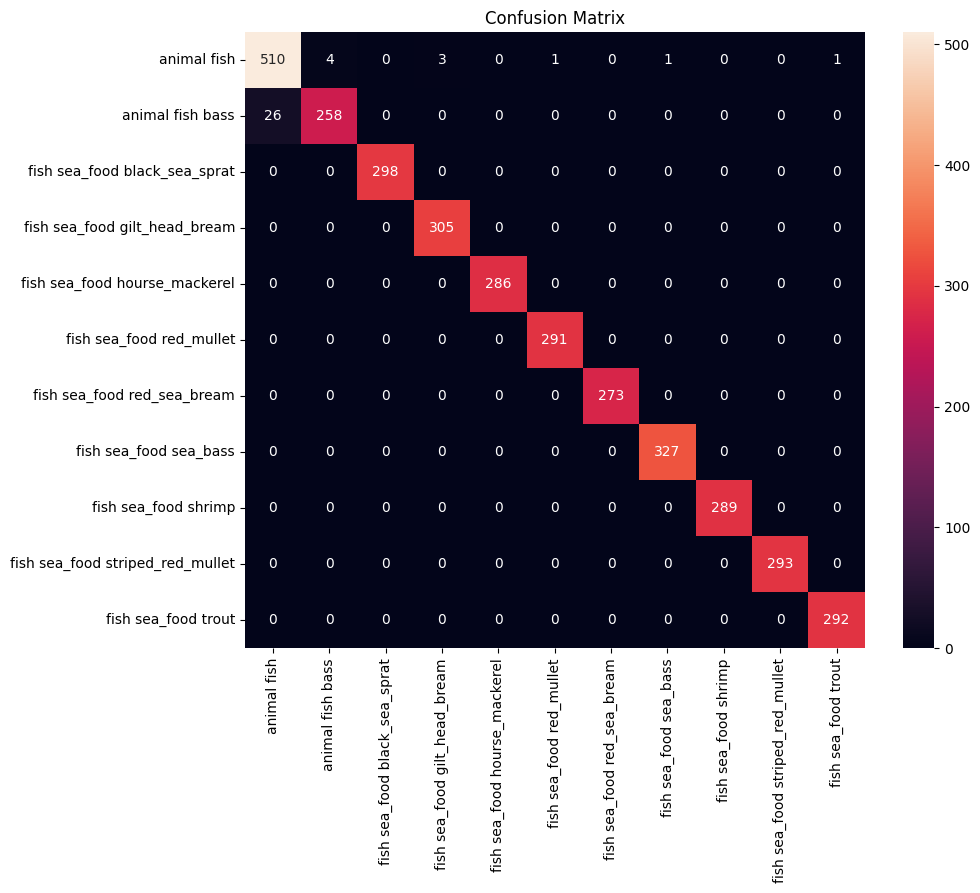


===== HEAD MODEL EVALUATION COMPLETED =====


In [ ]:
from tensorflow.keras.models import load_model
import json
import os

print("\n===== EVALUATING ALL HEAD MODELS (DIRECT FROM DRIVE) =====")

for name, cfg in BACKBONES.items():
    print(f"\n\n=== Evaluating HEAD model: {name} ===")

    # SELECT CORRECT MODEL PATH
    if name == "EfficientNetB0":
        model_path = os.path.join(SAVE_DIR, f"{name}_head.keras")
    else:
        model_path = os.path.join(SAVE_DIR, f"{name}_head.h5")

    if not os.path.exists(model_path):
        print("ERROR: Model file not found:", model_path)
        continue

    print("Loading model:", model_path)
    model = load_model(model_path)
    print("Model loaded successfully.")

    # BUILD TEST GENERATOR WITH CORRECT PREPROCESS
    _, _, test_gen_local = build_gens(cfg["pre"])

    # LOAD CLASS INDICES
    class_json = os.path.join(SAVE_DIR, f"{name}_class_indices.json")

    if os.path.exists(class_json):
        with open(class_json, "r") as f:
            class_indices = json.load(f)
        print("Loaded class indices from:", class_json)
    else:
        class_indices = test_gen_local.class_indices
        print("Using fallback class indices from generator.")

    # EVALUATE MODEL
    evaluate_and_report(model, test_gen_local, class_indices)

print("\n===== HEAD MODEL EVALUATION COMPLETED =====")

# Fine-tune function

In [ ]:
def fine_tune_model(saved_path, unfreeze_from_layer, lr=LR_FINETUNE, suffix="_finetuned"):
    import traceback
    from tensorflow.keras.models import load_model

    # Load head model
    model = load_model(saved_path)
    total_layers = len(model.layers)
    base_name = os.path.splitext(os.path.basename(saved_path))[0]

    print(f"\nLoaded model: {saved_path}  (total layers: {total_layers})")

    # UNFREEZE LOGIC
    if unfreeze_from_layer < 0:
        N = min(abs(unfreeze_from_layer), total_layers)
        for layer in model.layers[:-N]:
            layer.trainable = False
        for layer in model.layers[-N:]:
            layer.trainable = True
        print(f"Will unfreeze last {N} layers.")
    else:
        for layer in model.layers:
            layer.trainable = True
        print("Will unfreeze ALL layers.")

    # Print trainable layer summary
    trainable_layers = [(i, L.name) for i,L in enumerate(model.layers) if L.trainable]
    print(f"Trainable layers: {len(trainable_layers)}")
    for idx, name in trainable_layers[:25]:
        print(f"{idx:03d}  {name}")
    if len(trainable_layers) > 25:
        print("... (more omitted)")

    # COMPILE WITH LOW LR
    model.compile(optimizer=Adam(learning_rate=lr),
                  loss="categorical_crossentropy",
                  metrics=["accuracy"])

    # DETECT BACKBONE (for preprocess + checkpoint)
    matched_backbone = None
    for k in BACKBONES:
        if k.lower() in base_name.lower():
            matched_backbone = k
            break
    if matched_backbone is None:
        matched_backbone = "VGG16"  # fallback

    pre_fn = BACKBONES[matched_backbone]["pre"]

    # BUILD GENERATORS
    train_gen, val_gen, test_gen = build_gens(pre_fn)

    # CHECKPOINT SETUP
    try:
        if "efficientnet" in matched_backbone.lower():
            # ALWAYS save full model as .keras (SAFEST)
            ckpt_path = os.path.join(SAVE_DIR, f"{base_name}{suffix}.keras")
            checkpoint = ModelCheckpoint(
                ckpt_path,
                monitor='val_accuracy',
                save_best_only=True,
                save_weights_only=False,   # full model
                verbose=1,
                mode='max'
            )
            print(f"(EfficientNet) Saving full model as .keras → {ckpt_path}")

        else:
            # Save full model as .h5
            ckpt_path = os.path.join(SAVE_DIR, f"{base_name}{suffix}.h5")
            checkpoint = ModelCheckpoint(
                ckpt_path,
                monitor='val_accuracy',
                save_best_only=True,
                save_weights_only=False,
                verbose=1,
                mode='max'
            )
            print(f"Saving full model as .h5 → {ckpt_path}")

        callbacks = [
            checkpoint,
            ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=1, min_lr=1e-7, verbose=1),
            EarlyStopping(monitor='val_accuracy', patience=PATIENCE, restore_best_weights=True, verbose=1)
        ]

        # TRAIN
        history = model.fit(
            train_gen,
            validation_data=val_gen,
            epochs=EPOCHS_FINETUNE,
            callbacks=callbacks
        )

    except Exception as e:
        print("\nException during fine-tuning. Falling back → saving .keras")
        traceback.print_exc()
        ckpt_path = os.path.join(SAVE_DIR, f"{base_name}{suffix}_fallback.keras")
        model.save(ckpt_path)
        print(f"Saved fallback model: {ckpt_path}")
        history = None

    gc.collect()
    return history, ckpt_path

# Fine-tuning loop for all models



=== Fine-tuning VGG16 ===
Using head model: /content/drive/MyDrive/fish_models/VGG16_head.h5



Loaded model: /content/drive/MyDrive/fish_models/VGG16_head.h5  (total layers: 23)
Will unfreeze last 8 layers.
Trainable layers: 8
015  block5_conv1
016  block5_conv2
017  block5_conv3
018  block5_pool
019  global_average_pooling2d
020  dropout
021  dense
022  dense_1
Found 6753 images belonging to 11 classes.
Found 1179 images belonging to 11 classes.
Found 3490 images belonging to 11 classes.
Saving full model as .h5 → /content/drive/MyDrive/fish_models/VGG16_head_finetuned.h5


/usr/local/lib/python3.12/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/3
212/212 ━━━━━━━━━━━━━━━━━━━━ 0s 729ms/step - accuracy: 0.9044 - loss: 0.2921
Epoch 1: val_accuracy improved from -inf to 0.96947, saving model to /content/drive/MyDrive/fish_models/VGG16_head_finetuned.h5


212/212 ━━━━━━━━━━━━━━━━━━━━ 216s 871ms/step - accuracy: 0.9045 - loss: 0.2917 - val_accuracy: 0.9695 - val_loss: 0.0812 - learning_rate: 1.0000e-04
Epoch 2/3
212/212 ━━━━━━━━━━━━━━━━━━━━ 0s 658ms/step - accuracy: 0.9782 - loss: 0.0655
Epoch 2: val_accuracy improved from 0.96947 to 0.98643, saving model to /content/drive/MyDrive/fish_models/VGG16_head_finetuned.h5



Epoch 2: ReduceLROnPlateau reducing learning rate to 4.999999873689376e-05.
212/212 ━━━━━━━━━━━━━━━━━━━━ 151s 712ms/step - accuracy: 0.9782 - loss: 0.0655 - val_accuracy: 0.9864 - val_loss: 0.0877 - learning_rate: 1.0000e-04
Epoch 3/3
212/212 ━━━━━━━━━━━━━━━━━━━━ 0s 672ms/step - accuracy: 0.9908 - loss: 0.0308
Epoch 3: val_accuracy did not improve from 0.98643

Epoch 3: ReduceLROnPlateau reducing learning rate to 2.499999936844688e-05.
212/212 ━━━━━━━━━━━━━━━━━━━━ 152s 715ms/step - accuracy: 0.9909 - loss: 0.0307 - val_accuracy: 0.9864 - val_loss: 0.0930 - learning_rate: 5.0000e-05
Epoch 3: early stopping
Restoring model weights from the end of the best epoch: 2.


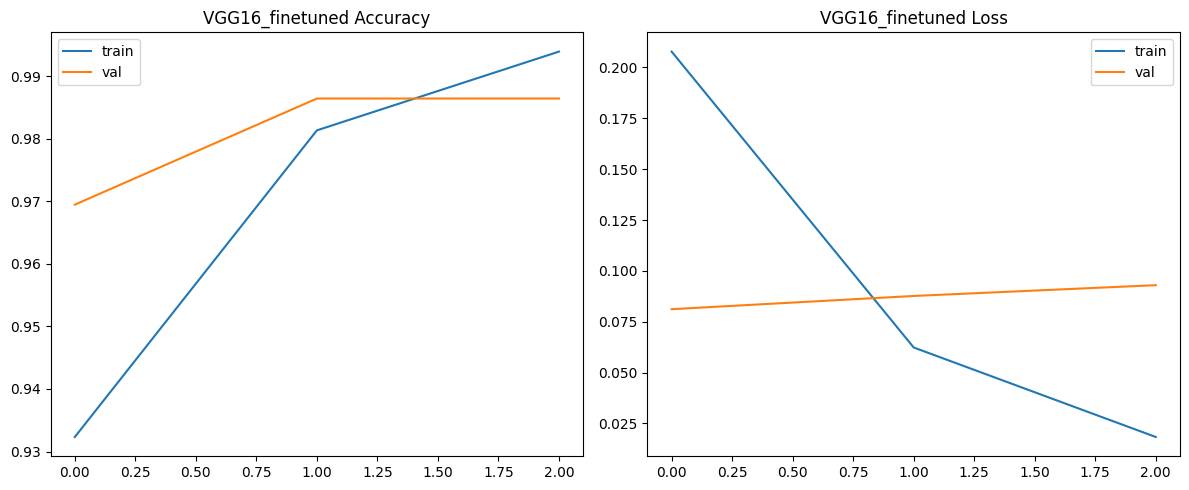

[SAVED] VGG16 fine-tuned model at: /content/drive/MyDrive/fish_models/VGG16_head_finetuned.h5


=== Fine-tuning ResNet50 ===
Using head model: /content/drive/MyDrive/fish_models/ResNet50_head.h5



Loaded model: /content/drive/MyDrive/fish_models/ResNet50_head.h5  (total layers: 179)
Will unfreeze last 50 layers.
Trainable layers: 50
129  conv4_block5_3_conv
130  conv4_block5_3_bn
131  conv4_block5_add
132  conv4_block5_out
133  conv4_block6_1_conv
134  conv4_block6_1_bn
135  conv4_block6_1_relu
136  conv4_block6_2_conv
137  conv4_block6_2_bn
138  conv4_block6_2_relu
139  conv4_block6_3_conv
140  conv4_block6_3_bn
141  conv4_block6_add
142  conv4_block6_out
143  conv5_block1_1_conv
144  conv5_block1_1_bn
145  conv5_block1_1_relu
146  conv5_block1_2_conv
147  conv5_block1_2_bn
148  conv5_block1_2_relu
149  conv5_block1_0_conv
150  conv5_block1_3_conv
151  conv5_block1_0_bn
152  conv5_block1_3_bn
153  conv5_block1_add
... (more omitted)
Found 6753 images belonging to 11 classes.
Found 1179 images belonging to 11 classes.
Found 3490 images belonging to 11 classes.
Saving full model as .h5 → /content/drive/MyDrive/fish_models/ResNet50_head_finetuned.h5
Epoch 1/3
212/212 ━━━━━━━━━━━━

212/212 ━━━━━━━━━━━━━━━━━━━━ 188s 755ms/step - accuracy: 0.9597 - loss: 0.1358 - val_accuracy: 0.9847 - val_loss: 0.0433 - learning_rate: 1.0000e-04
Epoch 2/3
212/212 ━━━━━━━━━━━━━━━━━━━━ 0s 639ms/step - accuracy: 0.9930 - loss: 0.0236
Epoch 2: val_accuracy improved from 0.98473 to 0.99915, saving model to /content/drive/MyDrive/fish_models/ResNet50_head_finetuned.h5


212/212 ━━━━━━━━━━━━━━━━━━━━ 146s 690ms/step - accuracy: 0.9930 - loss: 0.0236 - val_accuracy: 0.9992 - val_loss: 0.0028 - learning_rate: 1.0000e-04
Epoch 3/3
212/212 ━━━━━━━━━━━━━━━━━━━━ 0s 635ms/step - accuracy: 0.9938 - loss: 0.0184
Epoch 3: val_accuracy did not improve from 0.99915

Epoch 3: ReduceLROnPlateau reducing learning rate to 4.999999873689376e-05.
212/212 ━━━━━━━━━━━━━━━━━━━━ 196s 663ms/step - accuracy: 0.9938 - loss: 0.0184 - val_accuracy: 0.9941 - val_loss: 0.0194 - learning_rate: 1.0000e-04
Epoch 3: early stopping
Restoring model weights from the end of the best epoch: 2.


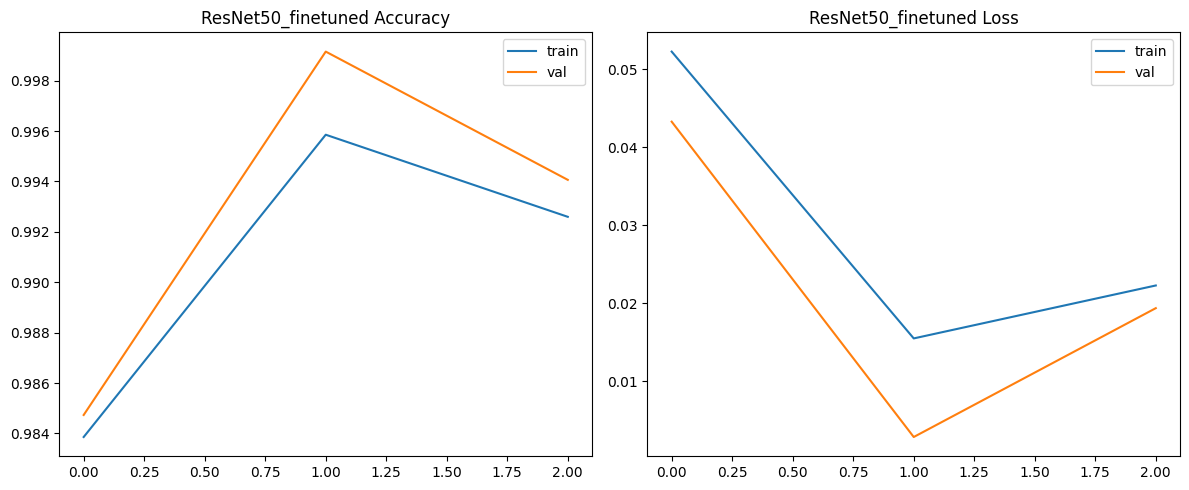

[SAVED] ResNet50 fine-tuned model at: /content/drive/MyDrive/fish_models/ResNet50_head_finetuned.h5


=== Fine-tuning MobileNet ===
Using head model: /content/drive/MyDrive/fish_models/MobileNet_head.h5



Loaded model: /content/drive/MyDrive/fish_models/MobileNet_head.h5  (total layers: 90)
Will unfreeze last 30 layers.
Trainable layers: 30
060  conv_pw_9_relu
061  conv_dw_10
062  conv_dw_10_bn
063  conv_dw_10_relu
064  conv_pw_10
065  conv_pw_10_bn
066  conv_pw_10_relu
067  conv_dw_11
068  conv_dw_11_bn
069  conv_dw_11_relu
070  conv_pw_11
071  conv_pw_11_bn
072  conv_pw_11_relu
073  conv_pad_12
074  conv_dw_12
075  conv_dw_12_bn
076  conv_dw_12_relu
077  conv_pw_12
078  conv_pw_12_bn
079  conv_pw_12_relu
080  conv_dw_13
081  conv_dw_13_bn
082  conv_dw_13_relu
083  conv_pw_13
084  conv_pw_13_bn
... (more omitted)
Found 6753 images belonging to 11 classes.
Found 1179 images belonging to 11 classes.
Found 3490 images belonging to 11 classes.
Saving full model as .h5 → /content/drive/MyDrive/fish_models/MobileNet_head_finetuned.h5
Epoch 1/3
212/212 ━━━━━━━━━━━━━━━━━━━━ 0s 660ms/step - accuracy: 0.8418 - loss: 0.8006
Epoch 1: val_accuracy improved from -inf to 0.98473, saving model to /co

212/212 ━━━━━━━━━━━━━━━━━━━━ 181s 754ms/step - accuracy: 0.8423 - loss: 0.7981 - val_accuracy: 0.9847 - val_loss: 0.0428 - learning_rate: 1.0000e-04
Epoch 2/3
212/212 ━━━━━━━━━━━━━━━━━━━━ 0s 580ms/step - accuracy: 0.9808 - loss: 0.0612
Epoch 2: val_accuracy improved from 0.98473 to 0.98643, saving model to /content/drive/MyDrive/fish_models/MobileNet_head_finetuned.h5


212/212 ━━━━━━━━━━━━━━━━━━━━ 130s 614ms/step - accuracy: 0.9808 - loss: 0.0611 - val_accuracy: 0.9864 - val_loss: 0.0318 - learning_rate: 1.0000e-04
Epoch 3/3
212/212 ━━━━━━━━━━━━━━━━━━━━ 0s 581ms/step - accuracy: 0.9872 - loss: 0.0367
Epoch 3: val_accuracy improved from 0.98643 to 0.98982, saving model to /content/drive/MyDrive/fish_models/MobileNet_head_finetuned.h5


212/212 ━━━━━━━━━━━━━━━━━━━━ 130s 612ms/step - accuracy: 0.9872 - loss: 0.0367 - val_accuracy: 0.9898 - val_loss: 0.0254 - learning_rate: 1.0000e-04
Restoring model weights from the end of the best epoch: 3.


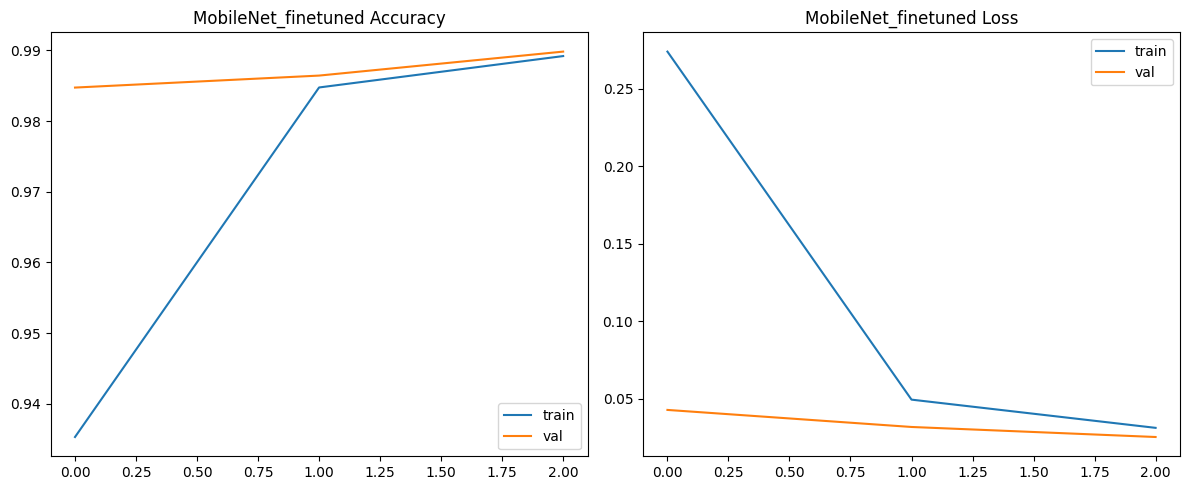

[SAVED] MobileNet fine-tuned model at: /content/drive/MyDrive/fish_models/MobileNet_head_finetuned.h5


=== Fine-tuning InceptionV3 ===
Using head model: /content/drive/MyDrive/fish_models/InceptionV3_head.h5



Loaded model: /content/drive/MyDrive/fish_models/InceptionV3_head.h5  (total layers: 315)
Will unfreeze last 50 layers.
Trainable layers: 50
265  batch_normalization_79
266  batch_normalization_82
267  batch_normalization_83
268  conv2d_84
269  batch_normalization_76
270  activation_78
271  activation_79
272  activation_82
273  activation_83
274  batch_normalization_84
275  activation_76
276  mixed9_0
277  concatenate
278  activation_84
279  mixed9
280  conv2d_89
281  batch_normalization_89
282  activation_89
283  conv2d_86
284  conv2d_90
285  batch_normalization_86
286  batch_normalization_90
287  activation_86
288  activation_90
289  conv2d_87
... (more omitted)
Found 6753 images belonging to 11 classes.
Found 1179 images belonging to 11 classes.
Found 3490 images belonging to 11 classes.
Saving full model as .h5 → /content/drive/MyDrive/fish_models/InceptionV3_head_finetuned.h5
Epoch 1/3
212/212 ━━━━━━━━━━━━━━━━━━━━ 0s 639ms/step - accuracy: 0.8778 - loss: 0.3988
Epoch 1: val_accur

212/212 ━━━━━━━━━━━━━━━━━━━━ 184s 739ms/step - accuracy: 0.8782 - loss: 0.3977 - val_accuracy: 0.9864 - val_loss: 0.0400 - learning_rate: 1.0000e-04
Epoch 2/3
212/212 ━━━━━━━━━━━━━━━━━━━━ 0s 597ms/step - accuracy: 0.9856 - loss: 0.0470
Epoch 2: val_accuracy did not improve from 0.98643

Epoch 2: ReduceLROnPlateau reducing learning rate to 4.999999873689376e-05.
212/212 ━━━━━━━━━━━━━━━━━━━━ 132s 621ms/step - accuracy: 0.9856 - loss: 0.0470 - val_accuracy: 0.9839 - val_loss: 0.0415 - learning_rate: 1.0000e-04
Epoch 2: early stopping
Restoring model weights from the end of the best epoch: 1.


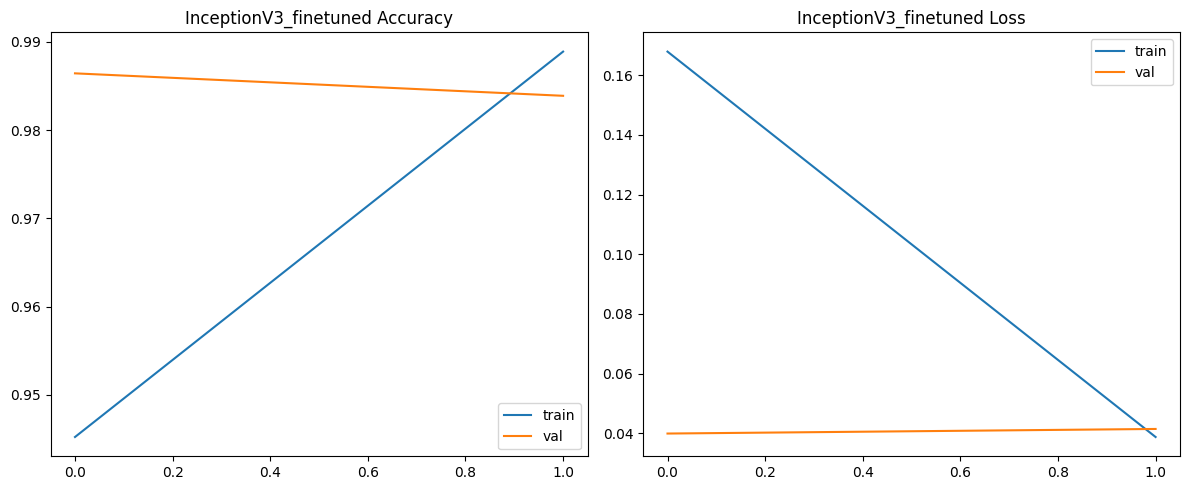

[SAVED] InceptionV3 fine-tuned model at: /content/drive/MyDrive/fish_models/InceptionV3_head_finetuned.h5


=== Fine-tuning EfficientNetB0 ===
Using head model: /content/drive/MyDrive/fish_models/EfficientNetB0_head.keras

Loaded model: /content/drive/MyDrive/fish_models/EfficientNetB0_head.keras  (total layers: 242)
Will unfreeze last 30 layers.
Trainable layers: 30
212  block6d_activation
213  block6d_se_squeeze
214  block6d_se_reshape
215  block6d_se_reduce
216  block6d_se_expand
217  block6d_se_excite
218  block6d_project_conv
219  block6d_project_bn
220  block6d_drop
221  block6d_add
222  block7a_expand_conv
223  block7a_expand_bn
224  block7a_expand_activation
225  block7a_dwconv
226  block7a_bn
227  block7a_activation
228  block7a_se_squeeze
229  block7a_se_reshape
230  block7a_se_reduce
231  block7a_se_expand
232  block7a_se_excite
233  block7a_project_conv
234  block7a_project_bn
235  top_conv
236  top_bn
... (more omitted)
Found 6753 images belonging to 11 classes.
Found 1179

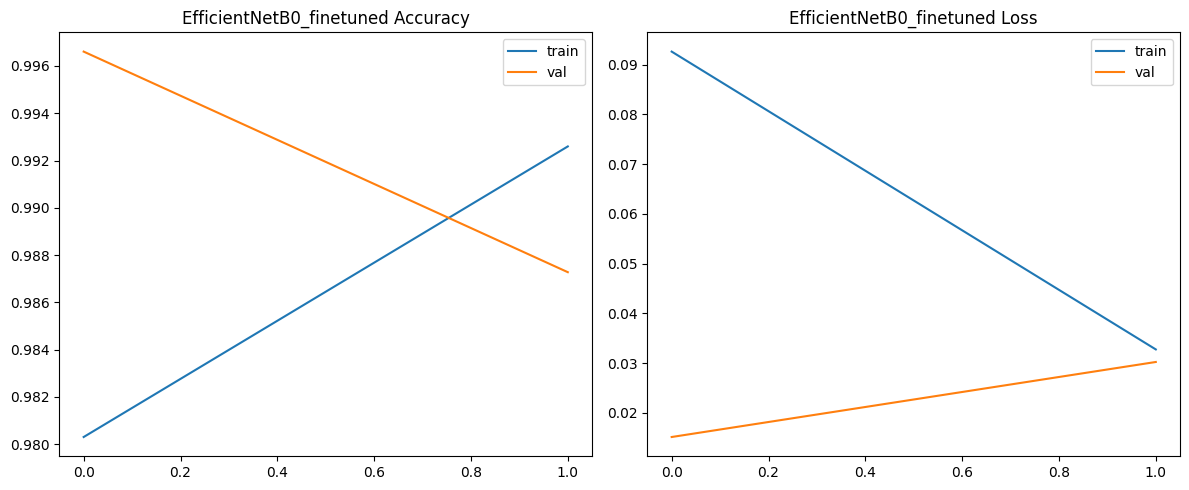

[SAVED] EfficientNetB0 fine-tuned model at: /content/drive/MyDrive/fish_models/EfficientNetB0_head_finetuned.keras


In [ ]:
ft_paths = {}

def head_path(name):
    if name == "EfficientNetB0":
        return os.path.join(SAVE_DIR, f"{name}_head.keras")
    else:
        return os.path.join(SAVE_DIR, f"{name}_head.h5")

for name, cfg in BACKBONES.items():
    print(f"\n\n=== Fine-tuning {name} ===")

    saved_head = head_path(name)
    if not os.path.exists(saved_head):
        print("ERROR: Head model not found:", saved_head)
        continue

    print("Using head model:", saved_head)

    # Fine-tune and save result
    history, ft_path = fine_tune_model(
        saved_head,
        unfreeze_from_layer=cfg["unfreeze"],
        lr=LR_FINETUNE,
        suffix="_finetuned"
    )

    # Plot only if training history was returned
    if history is not None:
        plot_training(history, f"{name}_finetuned")

    # Check saved file
    if os.path.exists(ft_path):
        print(f"[SAVED] {name} fine-tuned model at:", ft_path)
    else:
        print(f"[WARN] Fine-tuned file missing: {ft_path}")

    ft_paths[name] = ft_path
    gc.collect()

# Evaluating all finetuned models


===== EVALUATING ALL FINETUNED MODELS =====


=== Evaluating FINETUNED model: VGG16 ===


Model loaded.
Found 6753 images belonging to 11 classes.
Found 1179 images belonging to 11 classes.
Found 3490 images belonging to 11 classes.
Loaded saved class indices.
Evaluating...
110/110 ━━━━━━━━━━━━━━━━━━━━ 34s 302ms/step - accuracy: 0.9613 - loss: 0.2299
110/110 ━━━━━━━━━━━━━━━━━━━━ 27s 243ms/step

Classification Report:

                                  precision    recall  f1-score   support

                     animal fish       0.92      0.98      0.95       520
                animal fish bass       1.00      0.77      0.87       284
   fish sea_food black_sea_sprat       1.00      1.00      1.00       298
   fish sea_food gilt_head_bream       1.00      0.99      0.99       305
   fish sea_food hourse_mackerel       1.00      1.00      1.00       298
        fish sea_food red_mullet       0.99      1.00      0.99       291
     fish sea_food red_sea_bream       0.98      1.00      0.99       273
          fish sea_food sea_bass       0.99      1.00      1.00       327
 

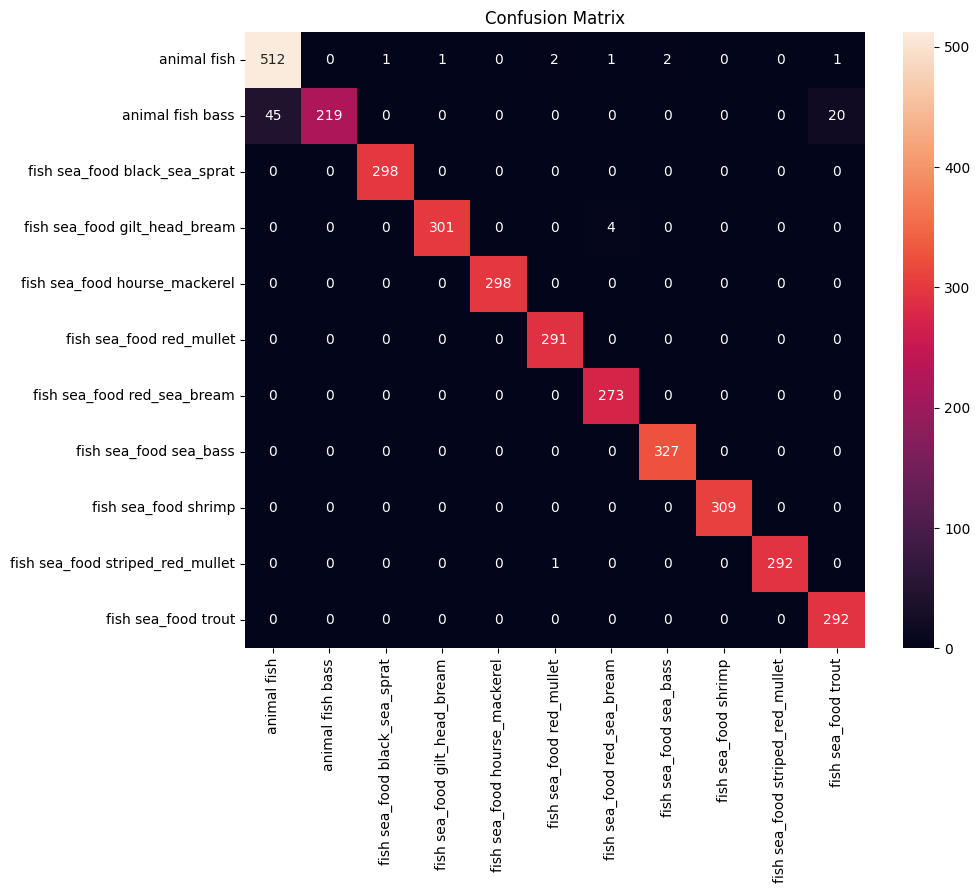



=== Evaluating FINETUNED model: ResNet50 ===


Model loaded.
Found 6753 images belonging to 11 classes.
Found 1179 images belonging to 11 classes.
Found 3490 images belonging to 11 classes.
Loaded saved class indices.
Evaluating...


/usr/local/lib/python3.12/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


110/110 ━━━━━━━━━━━━━━━━━━━━ 27s 188ms/step - accuracy: 0.9925 - loss: 0.0226
110/110 ━━━━━━━━━━━━━━━━━━━━ 26s 200ms/step

Classification Report:

                                  precision    recall  f1-score   support

                     animal fish       0.98      1.00      0.99       520
                animal fish bass       1.00      0.95      0.97       284
   fish sea_food black_sea_sprat       1.00      1.00      1.00       298
   fish sea_food gilt_head_bream       1.00      1.00      1.00       305
   fish sea_food hourse_mackerel       1.00      1.00      1.00       298
        fish sea_food red_mullet       1.00      1.00      1.00       291
     fish sea_food red_sea_bream       0.99      1.00      1.00       273
          fish sea_food sea_bass       1.00      1.00      1.00       327
            fish sea_food shrimp       1.00      1.00      1.00       309
fish sea_food striped_red_mullet       1.00      1.00      1.00       293
             fish sea_food trout      

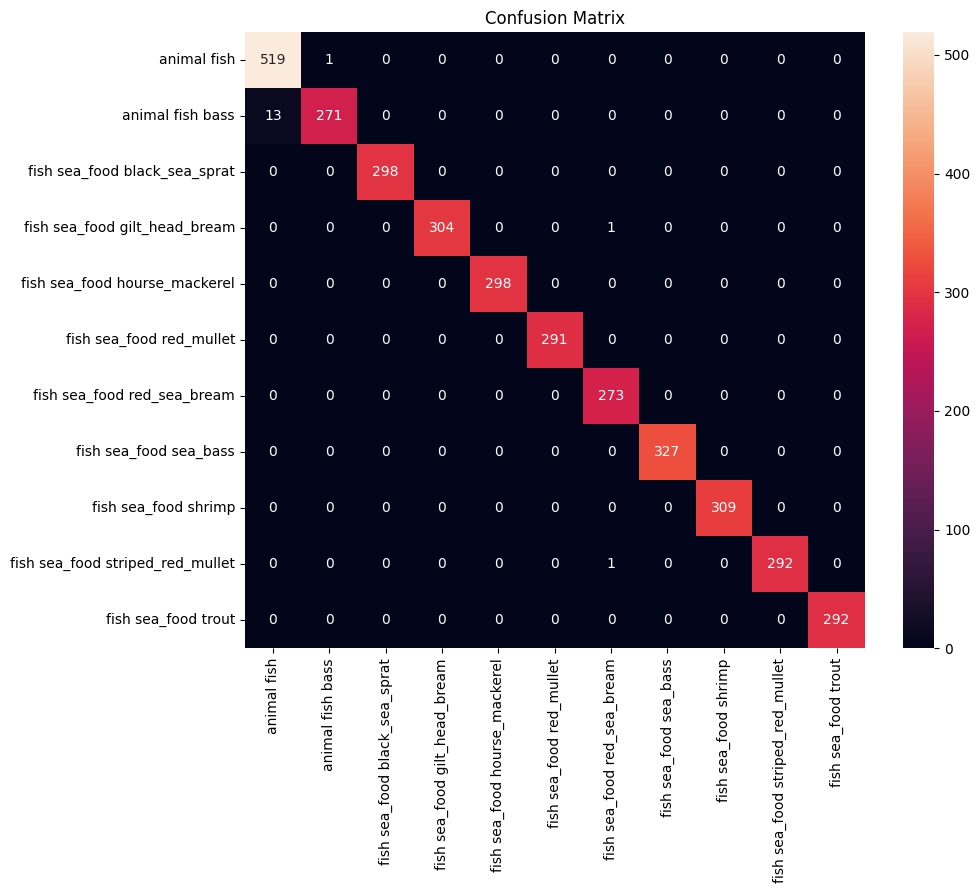



=== Evaluating FINETUNED model: MobileNet ===


Model loaded.
Found 6753 images belonging to 11 classes.
Found 1179 images belonging to 11 classes.
Found 3490 images belonging to 11 classes.
Loaded saved class indices.
Evaluating...


/usr/local/lib/python3.12/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


110/110 ━━━━━━━━━━━━━━━━━━━━ 29s 222ms/step - accuracy: 0.9738 - loss: 0.0921
110/110 ━━━━━━━━━━━━━━━━━━━━ 23s 180ms/step

Classification Report:

                                  precision    recall  f1-score   support

                     animal fish       0.90      1.00      0.95       520
                animal fish bass       1.00      0.81      0.89       284
   fish sea_food black_sea_sprat       1.00      1.00      1.00       298
   fish sea_food gilt_head_bream       1.00      1.00      1.00       305
   fish sea_food hourse_mackerel       1.00      1.00      1.00       298
        fish sea_food red_mullet       1.00      1.00      1.00       291
     fish sea_food red_sea_bream       1.00      1.00      1.00       273
          fish sea_food sea_bass       1.00      1.00      1.00       327
            fish sea_food shrimp       1.00      1.00      1.00       309
fish sea_food striped_red_mullet       1.00      1.00      1.00       293
             fish sea_food trout      

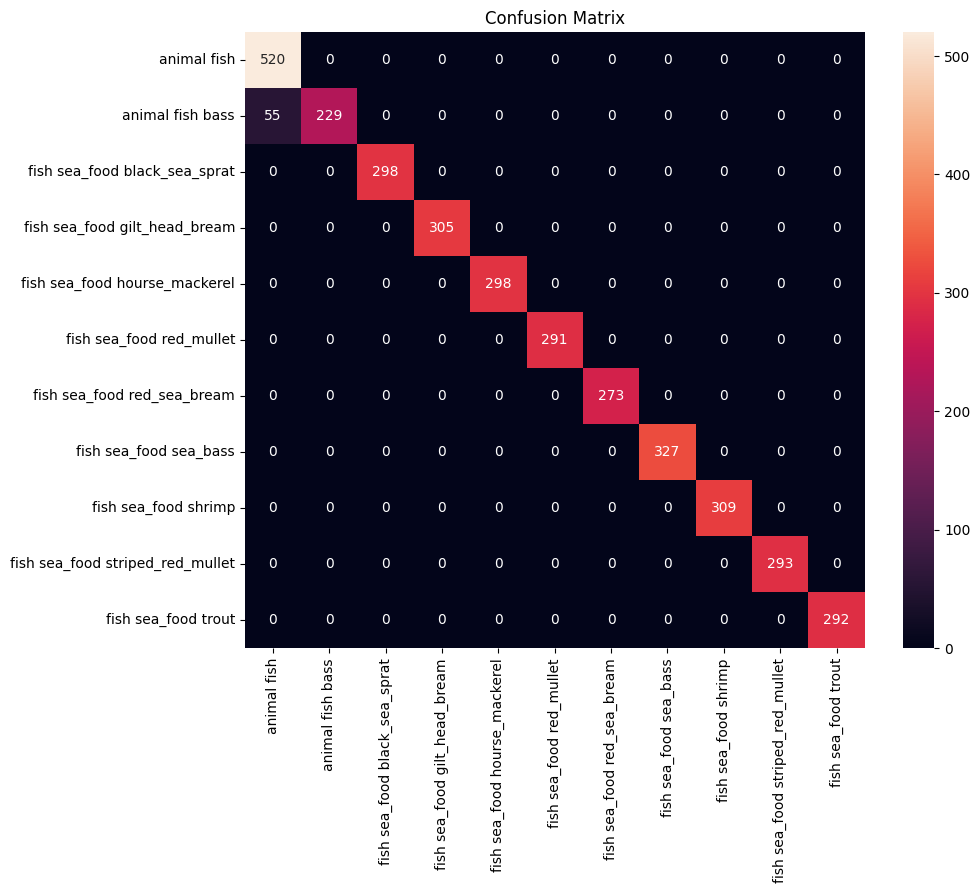



=== Evaluating FINETUNED model: InceptionV3 ===


Model loaded.
Found 6753 images belonging to 11 classes.
Found 1179 images belonging to 11 classes.
Found 3490 images belonging to 11 classes.
Loaded saved class indices.
Evaluating...


/usr/local/lib/python3.12/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


110/110 ━━━━━━━━━━━━━━━━━━━━ 31s 198ms/step - accuracy: 0.9858 - loss: 0.0973
110/110 ━━━━━━━━━━━━━━━━━━━━ 28s 206ms/step

Classification Report:

                                  precision    recall  f1-score   support

                     animal fish       0.96      1.00      0.98       520
                animal fish bass       0.99      0.92      0.95       284
   fish sea_food black_sea_sprat       1.00      1.00      1.00       298
   fish sea_food gilt_head_bream       1.00      1.00      1.00       305
   fish sea_food hourse_mackerel       1.00      1.00      1.00       298
        fish sea_food red_mullet       1.00      1.00      1.00       291
     fish sea_food red_sea_bream       1.00      1.00      1.00       273
          fish sea_food sea_bass       0.98      1.00      0.99       327
            fish sea_food shrimp       1.00      1.00      1.00       309
fish sea_food striped_red_mullet       1.00      0.99      0.99       293
             fish sea_food trout      

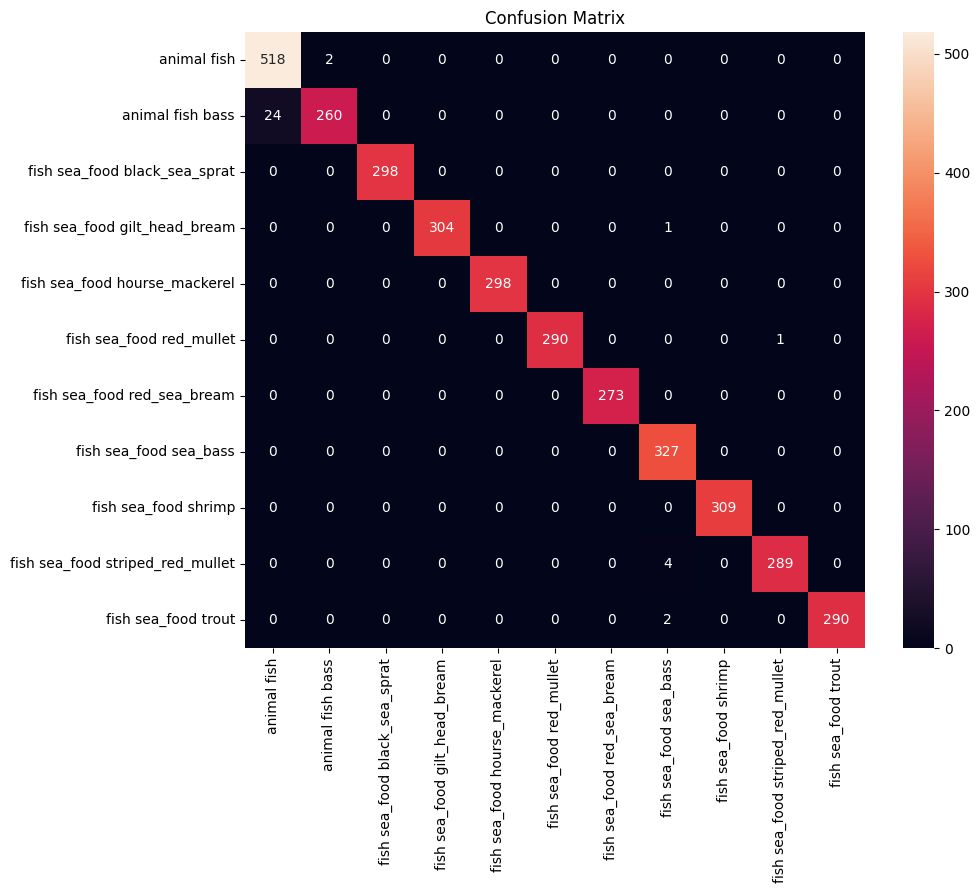



=== Evaluating FINETUNED model: EfficientNetB0 ===
Model loaded.
Found 6753 images belonging to 11 classes.
Found 1179 images belonging to 11 classes.
Found 3490 images belonging to 11 classes.
Loaded saved class indices.
Evaluating...


/usr/local/lib/python3.12/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


110/110 ━━━━━━━━━━━━━━━━━━━━ 34s 228ms/step - accuracy: 0.9851 - loss: 0.0561
110/110 ━━━━━━━━━━━━━━━━━━━━ 28s 202ms/step

Classification Report:

                                  precision    recall  f1-score   support

                     animal fish       0.96      0.99      0.97       520
                animal fish bass       0.99      0.92      0.95       284
   fish sea_food black_sea_sprat       1.00      1.00      1.00       298
   fish sea_food gilt_head_bream       1.00      1.00      1.00       305
   fish sea_food hourse_mackerel       1.00      1.00      1.00       298
        fish sea_food red_mullet       1.00      1.00      1.00       291
     fish sea_food red_sea_bream       1.00      1.00      1.00       273
          fish sea_food sea_bass       1.00      1.00      1.00       327
            fish sea_food shrimp       1.00      1.00      1.00       309
fish sea_food striped_red_mullet       1.00      1.00      1.00       293
             fish sea_food trout      

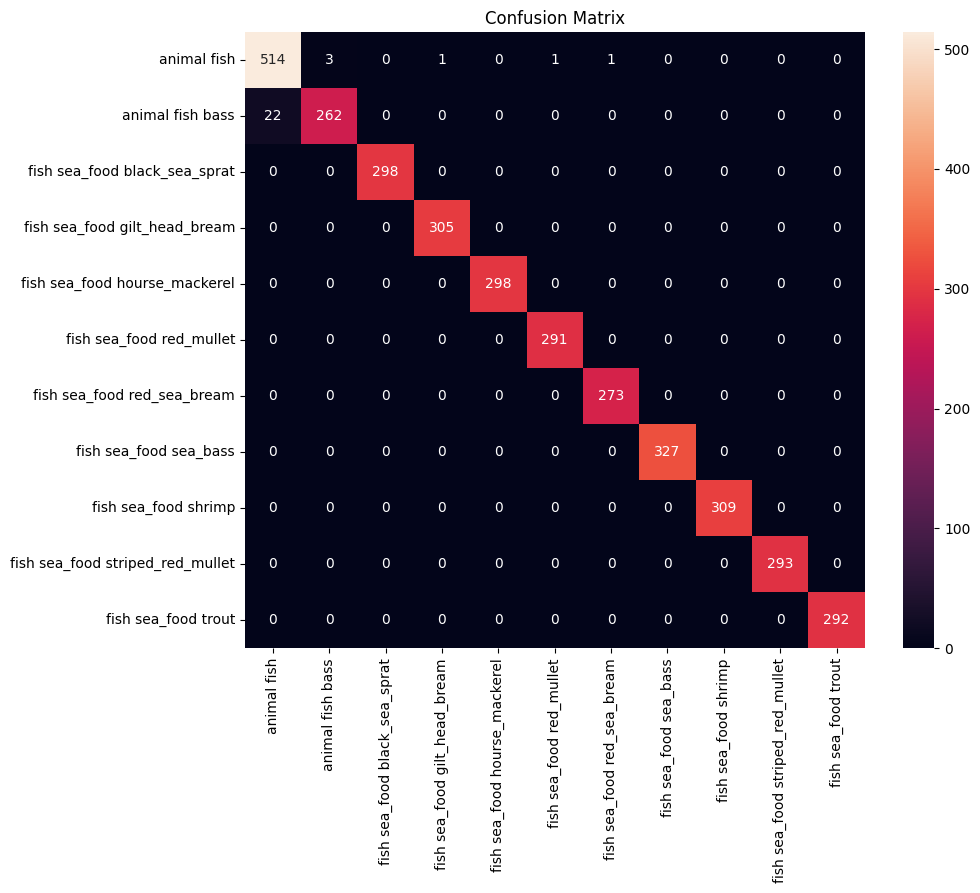

In [ ]:
print("\n===== EVALUATING ALL FINETUNED MODELS =====")

for name, path in ft_paths.items():
    print(f"\n\n=== Evaluating FINETUNED model: {name} ===")

    # Load model
    model = load_model(path)
    print("Model loaded.")

    # Build generator with correct preprocess
    _, _, test_gen_local = build_gens(BACKBONES[name]["pre"])

    # Load class indices JSON
    class_json = os.path.join(SAVE_DIR, f"{name}_class_indices.json")
    if os.path.exists(class_json):
        with open(class_json, "r") as f:
            class_indices = json.load(f)
        print("Loaded saved class indices.")
    else:
        class_indices = test_gen_local.class_indices  # fallback
        print("Using test_gen class indices (fallback).")

    # Evaluate
    evaluate_and_report(model, test_gen_local, class_indices)